# 1. INTRODUCTION
<center>
<img src="https://i.dailymail.co.uk/i/pix/2016/04/05/10/32DBE7DC00000578-0-image-a-23_1459850216223.jpg" width=1100 height=1000 />
</center>

**<font size="3">Data Description</font>**

<font size="3">Blueberries are perennial flowering plants with blue or purple berries. They are classified in the section Cyanococcus within the genus Vaccinium. Vaccinium also includes cranberries, bilberries, huckleberries, and Madeira blueberries. Commercial blueberries—both wild (lowbush) and cultivated (highbush)—are all native to North America. The highbush varieties were introduced into Europe during the 1930s.</font>

<font size="3">Blueberries are usually prostrate shrubs that can vary in size from 10 centimeters (4 inches) to 4 meters (13 feet) in height. In the commercial production of blueberries, the species with small, pea-size berries growing on low-level bushes are known as "lowbush blueberries" (synonymous with "wild"), while the species with larger berries growing on taller, cultivated bushes are known as "highbush blueberries". Canada is the leading producer of lowbush blueberries, while the United States produces some 40% of the world s supply of highbush blueberries.</font>

<font size="3">**Features Unit Description**
1. **Clonesize(m2)**: The average blueberry clone size in the field
2. **Honeybee (bees/m2/min)**: Honeybee density in the field
3. **Bumbles (bees/m2/min)**: Bumblebee density in the field
4. **Andrena (bees/m2/min)**: Andrena bee density in the field
5. **Osmia (bees/m2/min)**: Osmia bee density in the field
6. **MaxOfUpperTRange (℃)**: The highest record of the upper band daily air temperature during the bloom season
7. **MinOfUpperTRange (℃)**: The lowest record of the upper band daily air temperature7. 
8. **AverageOfUpperTRange (℃)**: The average of the upper band daily air temperature
9. **MaxOfLowerTRange (℃)**: The highest record of the lower band daily air temperature
10. **MinOfLowerTRange (℃)**: The lowest record of the lower band daily air temperature
11. **AverageOfLowerTRange (℃)**: The average of the lower band daily air temperature
12. **RainingDays**: Day The total number of days during the bloom season, each of which has precipitation larger than zero
13. **AverageRainingDays**: Day The average of raining days of the entire bloom season</font>

# 2. IMPORT LIBRARIES & DATA

In [17]:
import sys
assert sys.version_info >= (3, 5)

import sklearn
assert sklearn.__version__ >= "0.20"
import numpy as np
import os

import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
from prettytable import PrettyTable
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
from copy import deepcopy
from functools import partial
from itertools import combinations

from sklearn.cluster import KMeans
!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer

import random
from random import uniform
import gc
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xg
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_squared_log_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler,PowerTransformer, FunctionTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from scipy import stats
import statsmodels.api as sm
import math
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import BaseEstimator, TransformerMixin
!pip install optuna
import optuna
import xgboost as xgb
!pip install catboost
!pip install lightgbm --install-option=--gpu --install-option="--boost-root=C:/local/boost_1_69_0" --install-option="--boost-librarydir=C:/local/boost_1_69_0/lib64-msvc-14.1"
import lightgbm as lgb
!pip install category_encoders
from category_encoders import OneHotEncoder, OrdinalEncoder, CountEncoder, CatBoostEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import PassiveAggressiveRegressor, ARDRegression, RidgeCV, ElasticNetCV
from sklearn.linear_model import TheilSenRegressor, RANSACRegressor, HuberRegressor
from sklearn.ensemble import HistGradientBoostingRegressor,ExtraTreesRegressor,GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoost, CatBoostRegressor
from catboost import Pool
from sklearn.neighbors import KNeighborsRegressor
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option('display.max_columns',None)

DEPRECATION: --install-option is deprecated because it forces pip to use the 'setup.py install' command which is itself deprecated. pip 23.1 will enforce this behaviour change. A possible replacement is to use --config-settings. Discussion can be found at https://github.com/pypa/pip/issues/11358
DEPRECATION: --no-binary currently disables reading from the cache of locally built wheels. In the future --no-binary will not influence the wheel cache. pip 23.1 will enforce this behaviour change. A possible replacement is to use the --no-cache-dir option. You can use the flag --use-feature=no-binary-enable-wheel-cache to test the upcoming behaviour. Discussion can be found at https://github.com/pypa/pip/issues/11453


In [18]:
train=pd.read_csv('/kaggle/input/playground-series-s3e14/train.csv')
test=pd.read_csv('/kaggle/input/playground-series-s3e14/test.csv')

original=pd.read_csv("/kaggle/input/wild-blueberry-yield-prediction-dataset/WildBlueberryPollinationSimulationData.csv")
original["original"]=1
train["original"]=0
test["original"]=0
train.drop(columns=["id"],inplace=True)
test.drop(columns=["id"],inplace=True)
original.drop(columns=["Row#"],inplace=True)

train=pd.concat([train,original],axis=0)
train.reset_index(inplace=True,drop=True)

In [19]:
train.head()

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield,original
0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146,0
1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201,0
2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760,0
3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590,0
4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417,0


## 2.1 Check Missing Values

In [20]:
table = PrettyTable()

table.field_names = ['Column Name', 'Data Type', 'Non-Null Count']
for column in train.columns:
    data_type = str(train[column].dtype)
    non_null_count = train[column].count()
    table.add_row([column, data_type, non_null_count])
print(table)

+----------------------+-----------+----------------+
|     Column Name      | Data Type | Non-Null Count |
+----------------------+-----------+----------------+
|      clonesize       |  float64  |     16066      |
|       honeybee       |  float64  |     16066      |
|       bumbles        |  float64  |     16066      |
|       andrena        |  float64  |     16066      |
|        osmia         |  float64  |     16066      |
|   MaxOfUpperTRange   |  float64  |     16066      |
|   MinOfUpperTRange   |  float64  |     16066      |
| AverageOfUpperTRange |  float64  |     16066      |
|   MaxOfLowerTRange   |  float64  |     16066      |
|   MinOfLowerTRange   |  float64  |     16066      |
| AverageOfLowerTRange |  float64  |     16066      |
|     RainingDays      |  float64  |     16066      |
|  AverageRainingDays  |  float64  |     16066      |
|       fruitset       |  float64  |     16066      |
|      fruitmass       |  float64  |     16066      |
|        seeds         |  fl

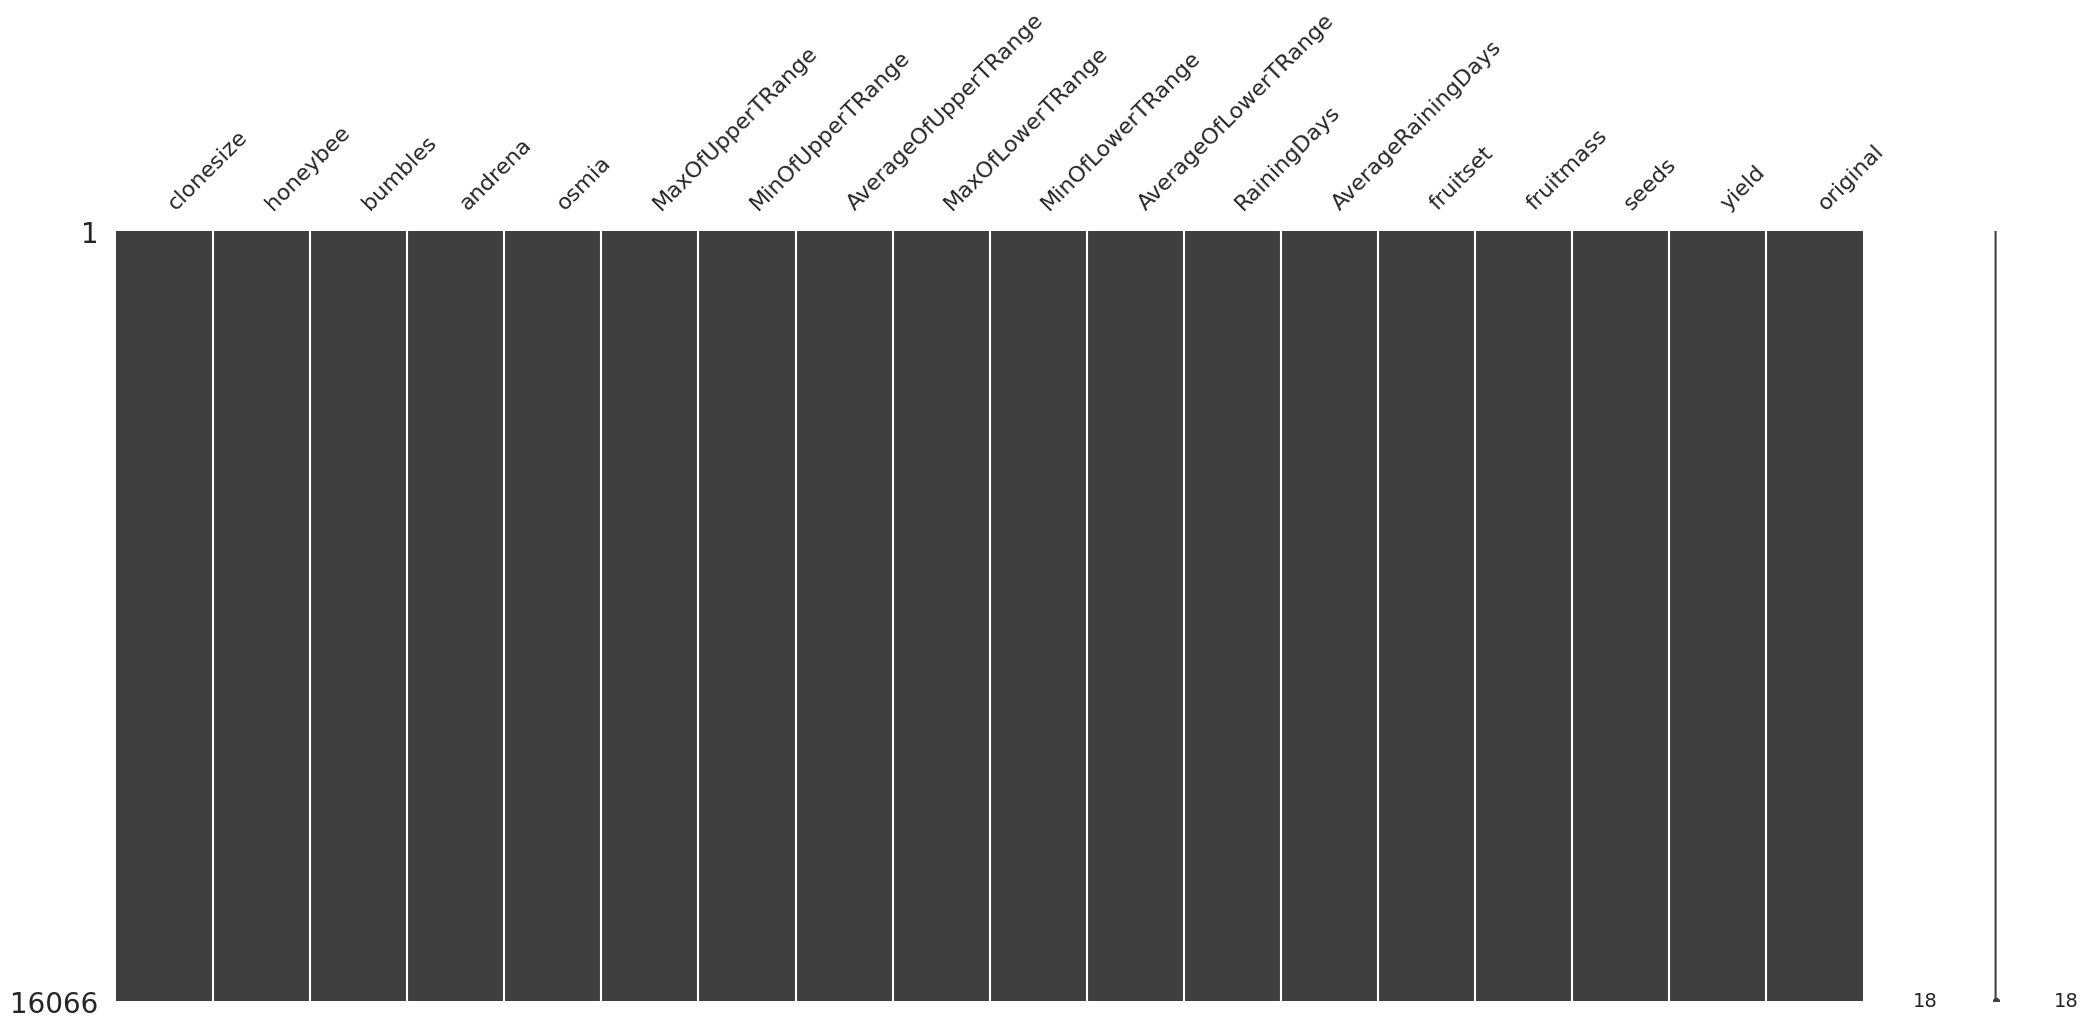

In [21]:
msno.matrix(train)
plt.show()

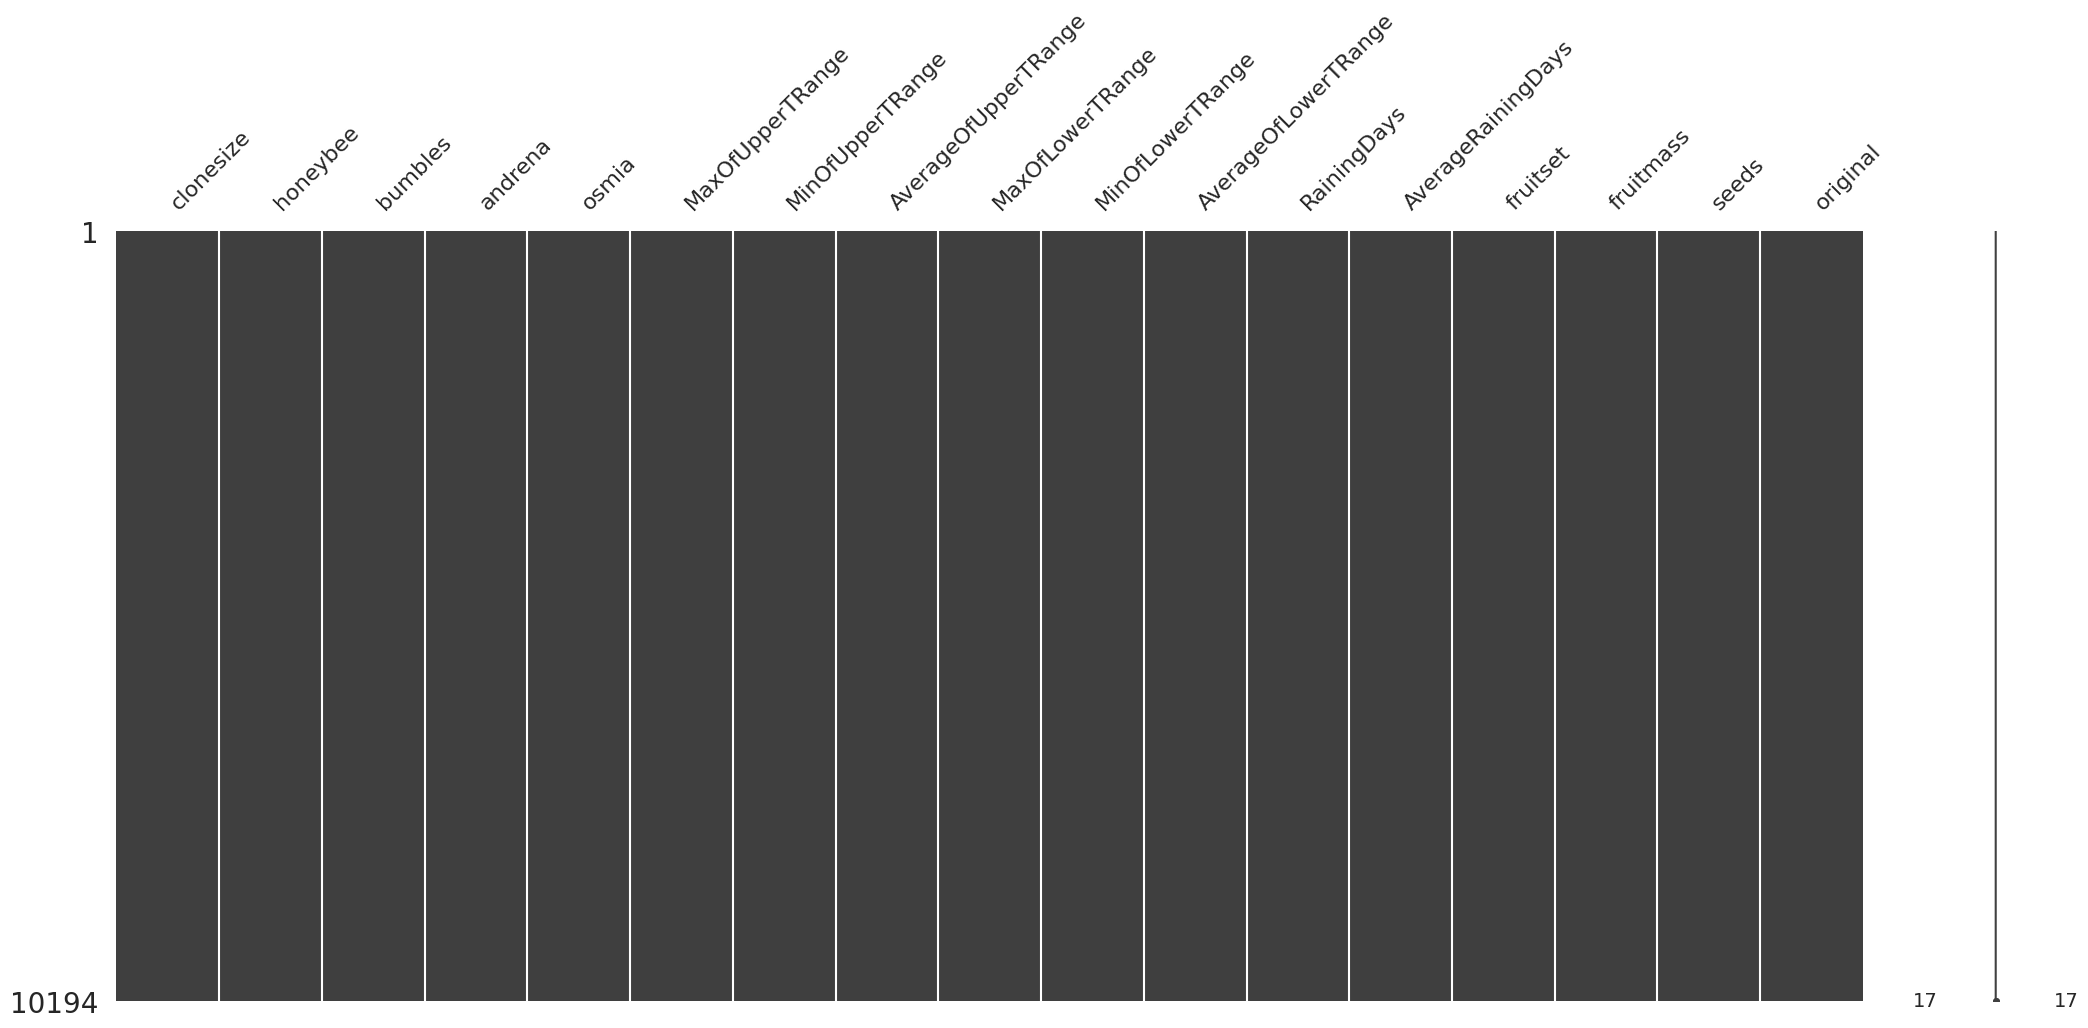

In [22]:
msno.matrix(test)
plt.show()

<font size="3">There are no missing values in the datasets</font>

# 3. Exploratory Data Analysis

## 3.1 Target Analysis

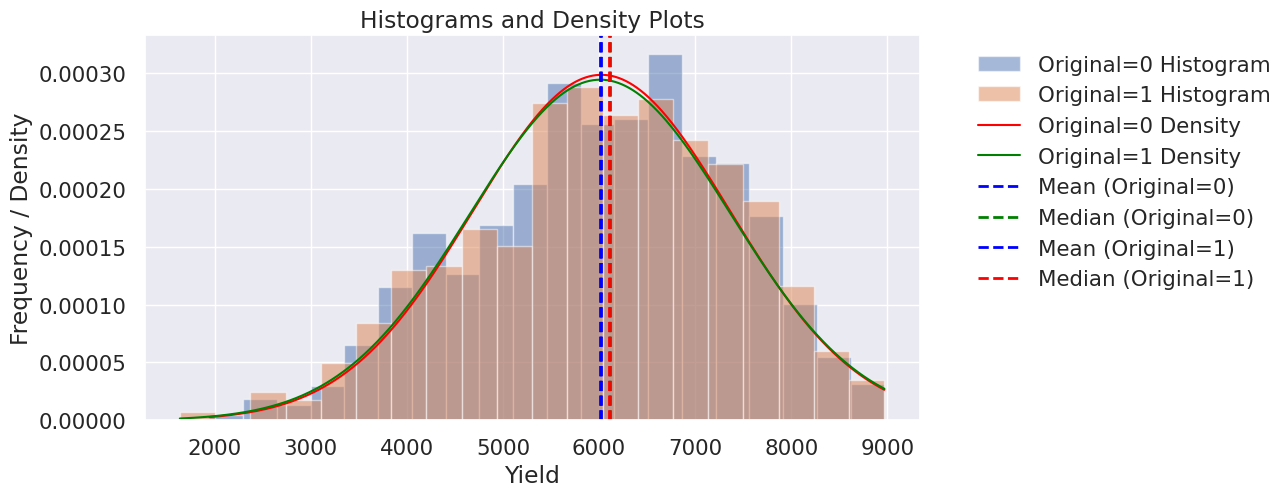

In [23]:
class_0 = train[train['original'] == 0]['yield']
class_1 = train[train['original'] == 1]['yield']

# Calculate the mean and median values for each class
mean_0 = np.mean(class_0)
median_0 = np.median(class_0)
mean_1 = np.mean(class_1)
median_1 = np.median(class_1)

fig, ax = plt.subplots(figsize=(10, 5))

# Plot histograms for each class
ax.hist(class_0, bins=20, density=True, alpha=0.5, label='Original=0 Histogram')
ax.hist(class_1, bins=20, density=True, alpha=0.5, label='Original=1 Histogram')

# Plot density plots for each class
x_values_0 = np.linspace(class_0.min(), class_0.max(), len(class_0))
density_values_0 = (1 / (np.sqrt(2 * np.pi) * np.std(class_0))) * np.exp(-0.5 * ((x_values_0 - mean_0) / np.std(class_0))**2)
ax.plot(x_values_0, density_values_0, color='red', label='Original=0 Density')

x_values_1 = np.linspace(class_1.min(), class_1.max(), len(class_1))
density_values_1 = (1 / (np.sqrt(2 * np.pi) * np.std(class_1))) * np.exp(-0.5 * ((x_values_1 - mean_1) / np.std(class_1))**2)
ax.plot(x_values_1, density_values_1, color='green', label='Original=1 Density')

# Add mean and median lines for each class
ax.axvline(mean_0, color='blue', linestyle='dashed', linewidth=2, label='Mean (Original=0)')
ax.axvline(median_0, color='green', linestyle='dashed', linewidth=2, label='Median (Original=0)')
ax.axvline(mean_1, color='blue', linestyle='dashed', linewidth=2, label='Mean (Original=1)')
ax.axvline(median_1, color='red', linestyle='dashed', linewidth=2, label='Median (Original=1)')

# Set axis labels and title
ax.set_xlabel('Yield')
ax.set_ylabel('Frequency / Density')
ax.set_title('Histograms and Density Plots')

# Move legend outside the right end of the chart
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


<font size="3"> We can see that both the original dataset and synthetic data have same distributions, mean, & median </font>

## 3.2 Numerical Features Analysis

<a id="3.2.1"></a>
### 3.2.1 Train & Test Data Distributions

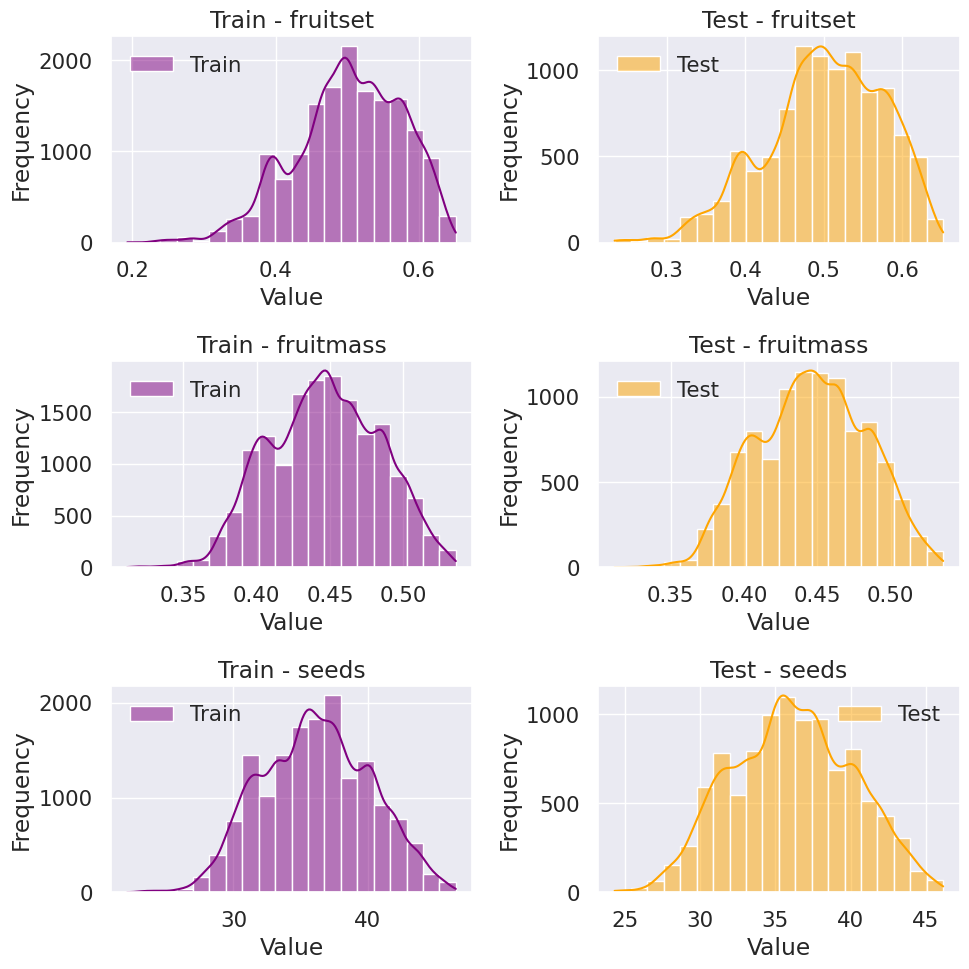

In [24]:
cont_cols=[f for f in train.columns if f not in ["yield", "original"] and train[f].nunique()>100]

# Create subplots for each continuous column
fig, axs = plt.subplots(len(cont_cols), 2, figsize=(10,10))

# Loop through each continuous column and plot the histograms
for i, col in enumerate(cont_cols):
    # Determine the range of values to plot
    max_val = max(train[col].max(), test[col].max())
    min_val = min(train[col].min(), test[col].min())
    range_val = max_val - min_val
    
    # Determine the bin size and number of bins
    bin_size = range_val / 20
    num_bins_train = round(range_val / bin_size)
    num_bins_test = round(range_val / bin_size)
    
    # Plot the histograms
    sns.histplot(train[col], ax=axs[i][0], color='purple', kde=True, label='Train', bins=num_bins_train)
    sns.histplot(test[col], ax=axs[i][1], color='orange', kde=True, label='Test', bins=num_bins_test)
    axs[i][0].set_title(f'Train - {col}')
    axs[i][0].set_xlabel('Value')
    axs[i][0].set_ylabel('Frequency')
    axs[i][1].set_title(f'Test - {col}')
    axs[i][1].set_xlabel('Value')
    axs[i][1].set_ylabel('Frequency')
    axs[i][0].legend()
    axs[i][1].legend()

plt.tight_layout()
plt.show()

<font size="3"> We can see that only three features have normal distributions(transformations would make this even better), The other columns are discrete

## 3.3 Discrete Feature Analysis

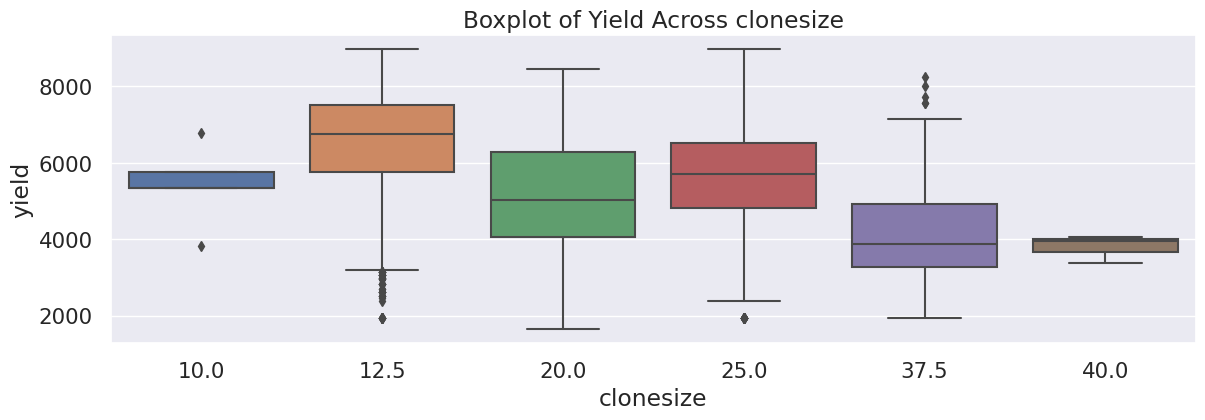

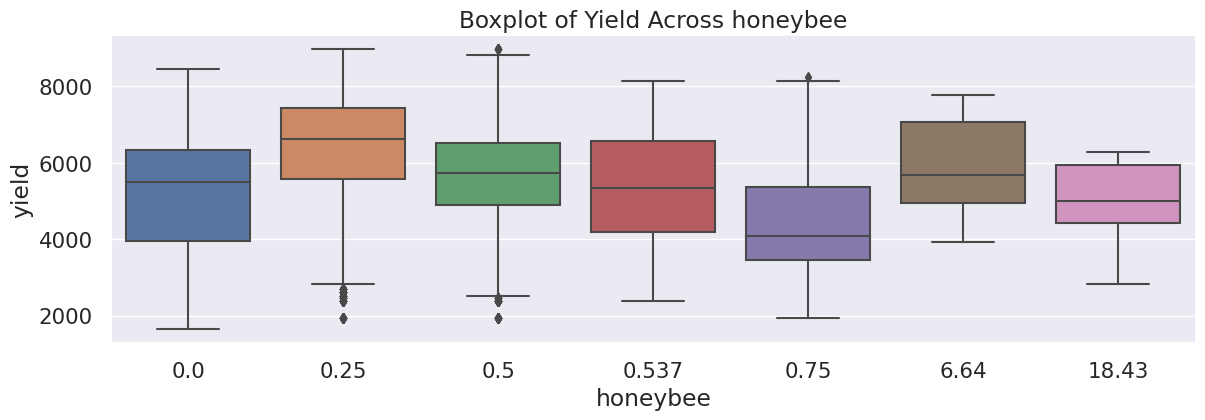

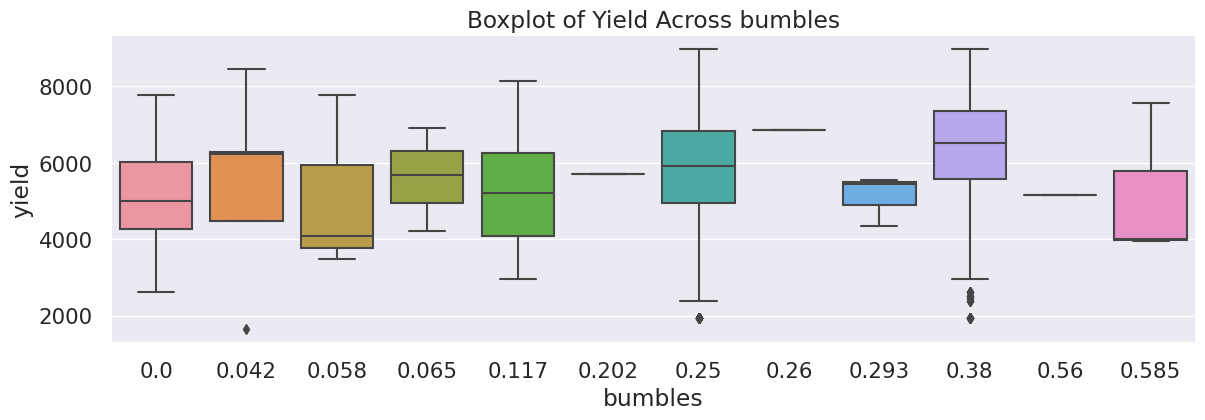

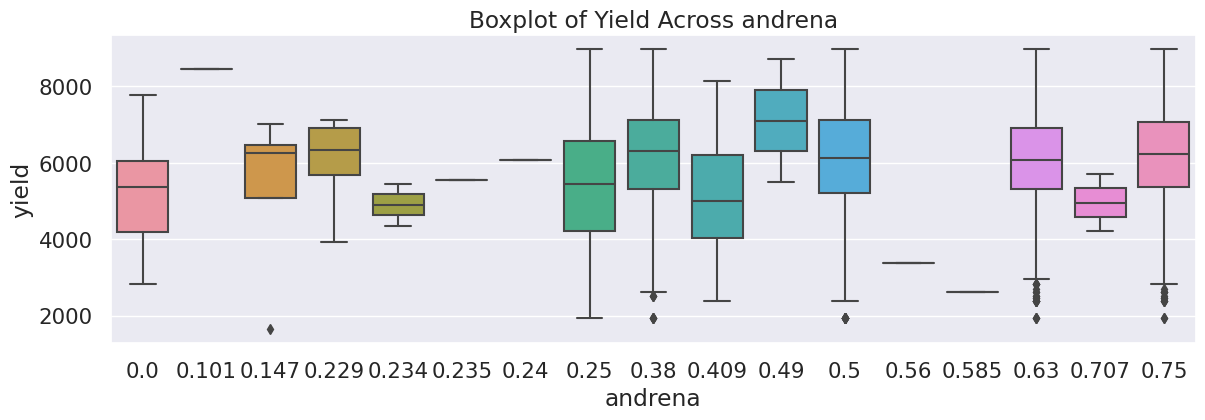

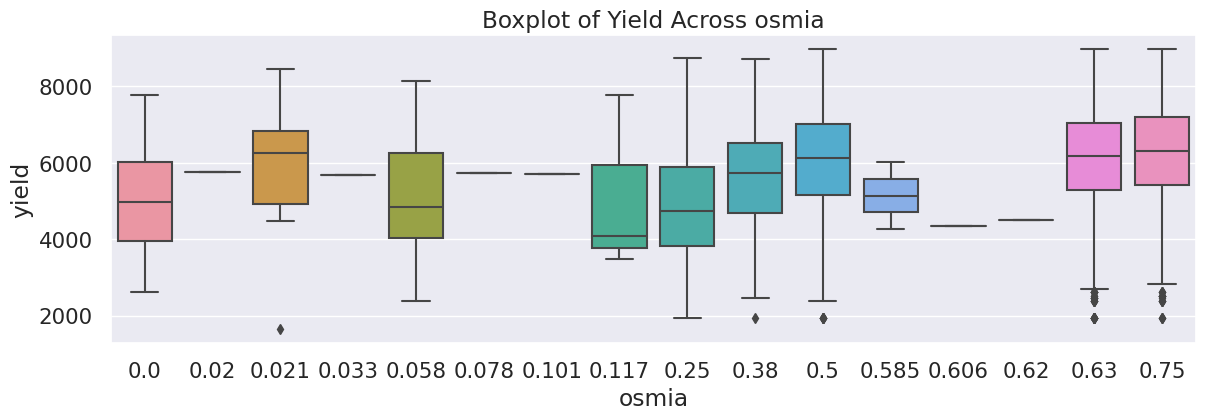

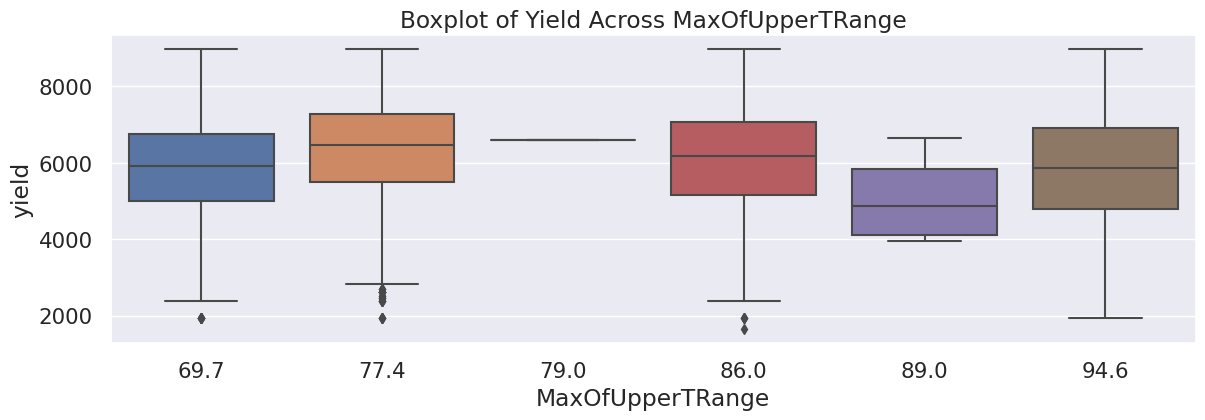

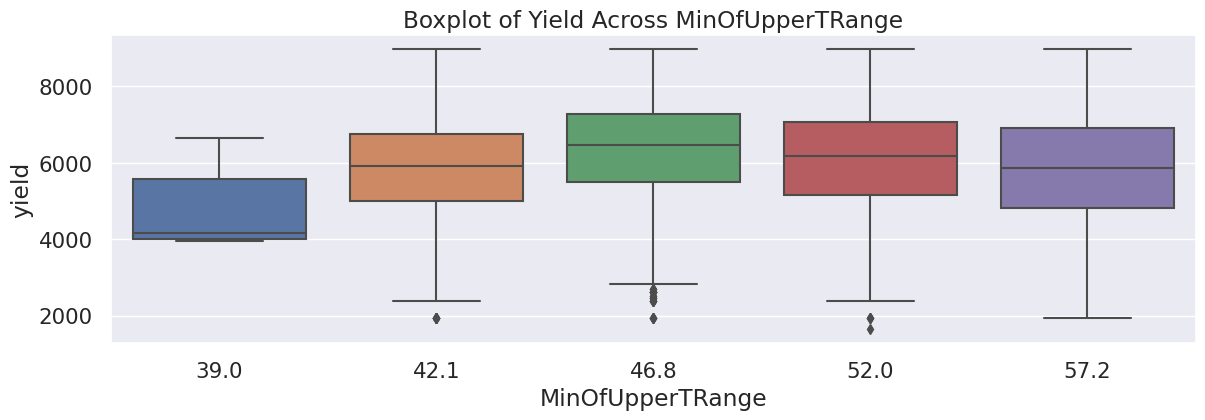

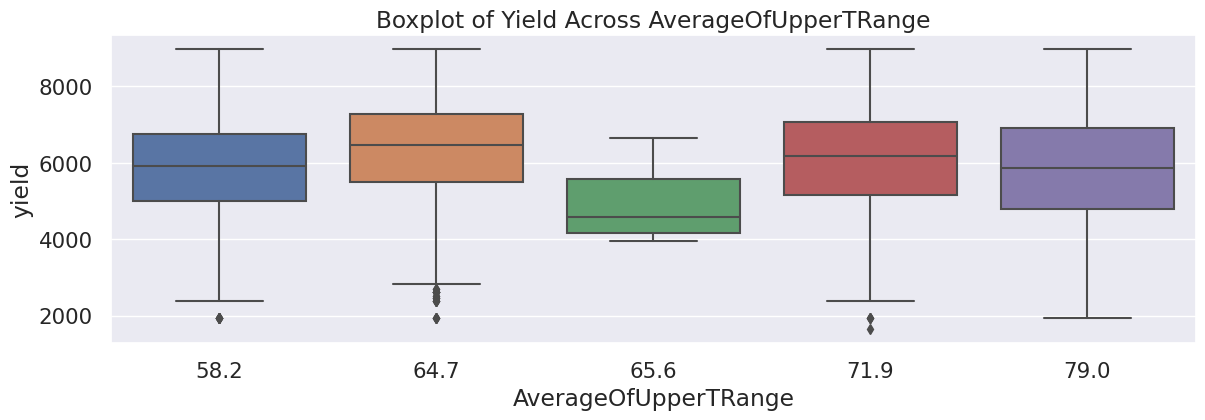

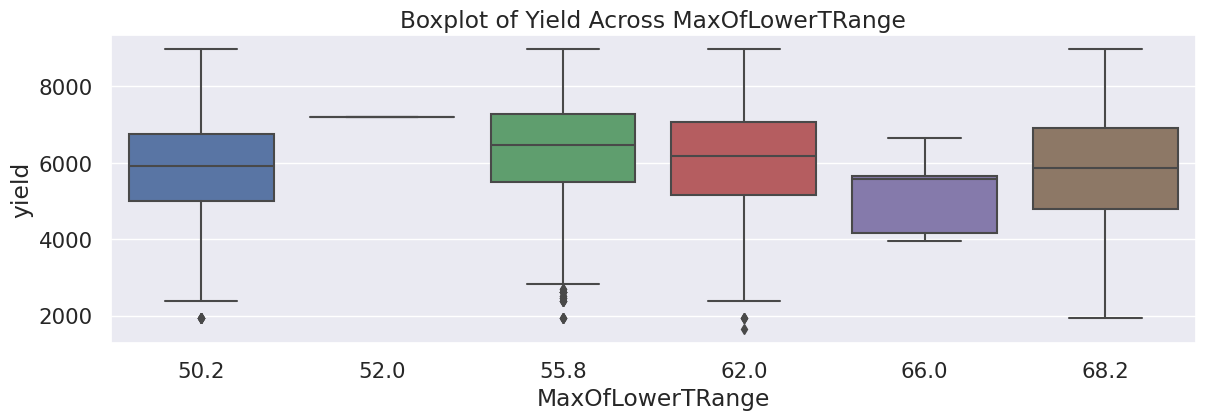

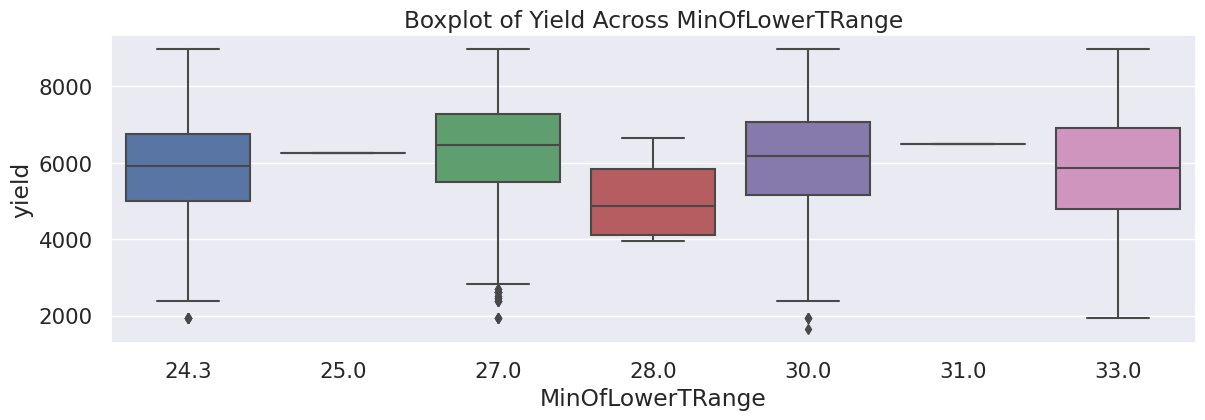

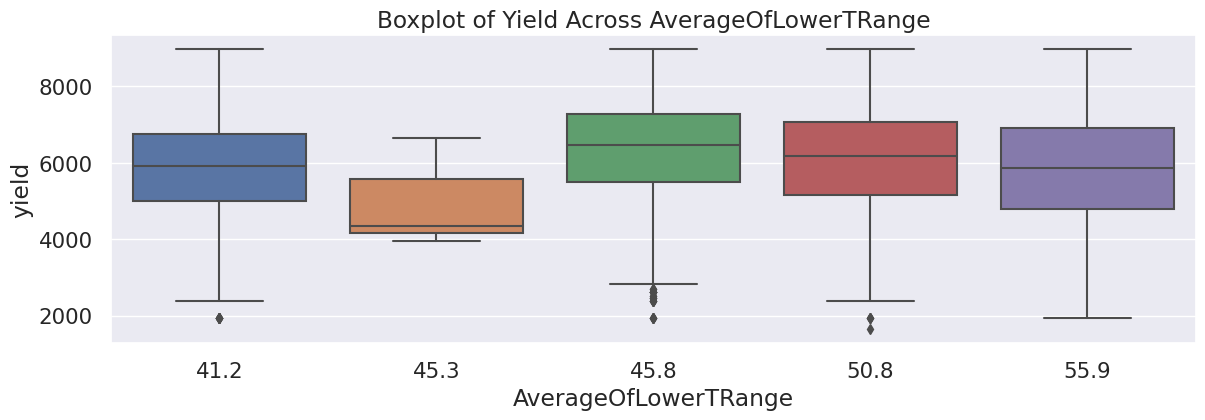

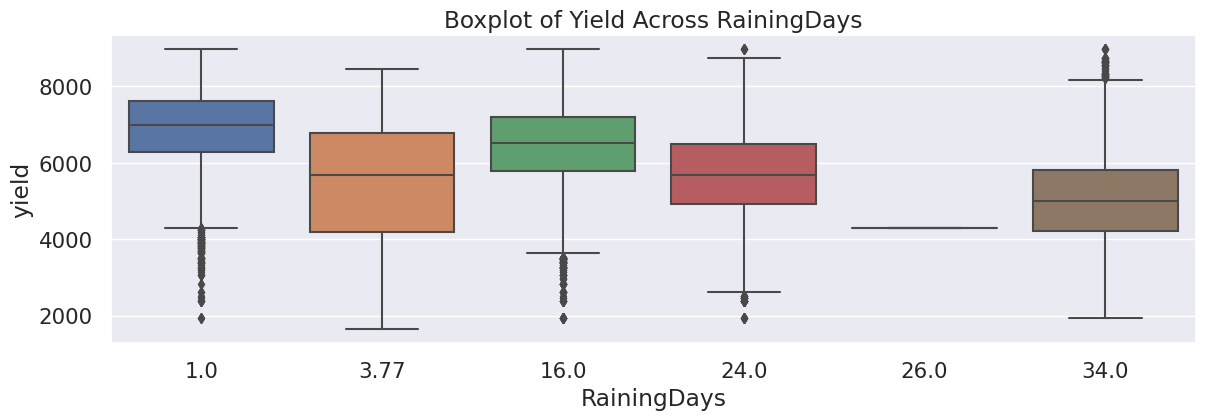

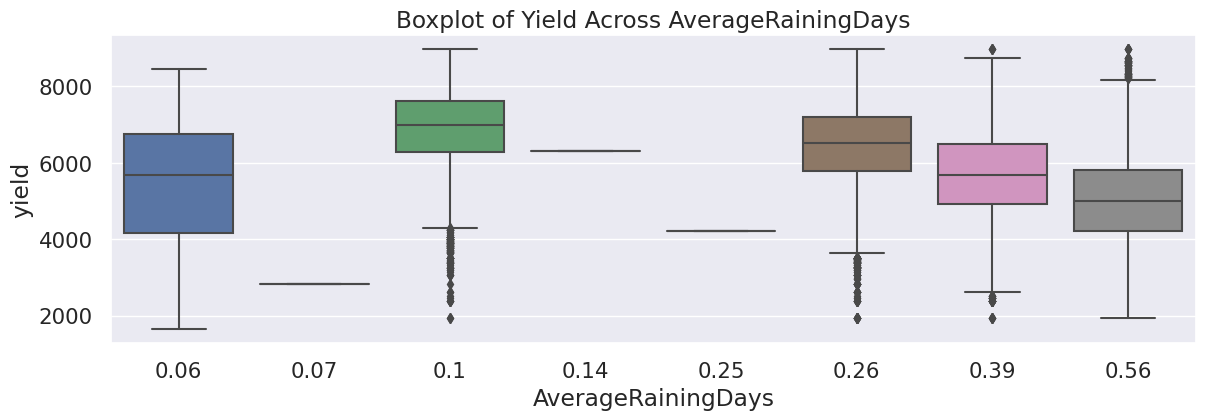

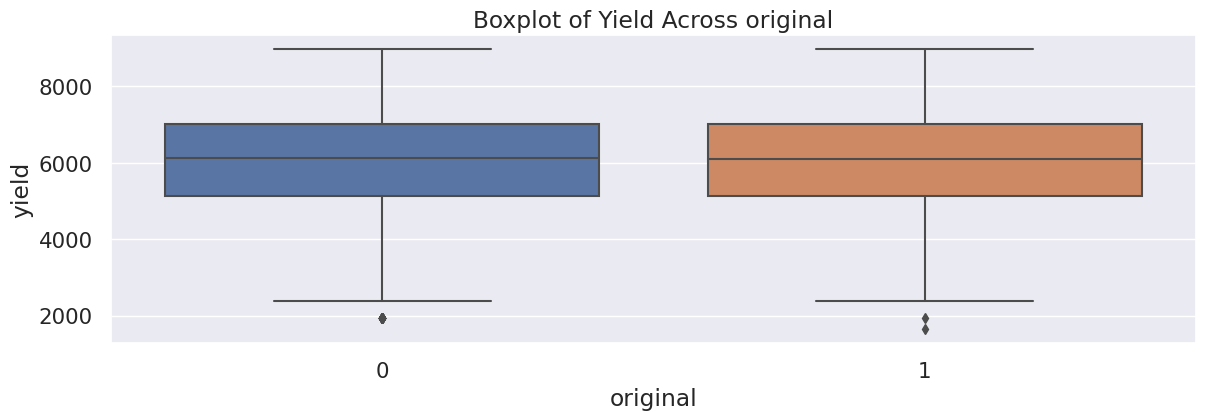

In [25]:
cat_cols=[f for f in train.columns if f not in ["yield"] and train[f].nunique()<=100]
for var in cat_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.boxplot(x=var, y='yield', data=train, ax=ax)
    ax.set_title(f'Boxplot of Yield Across {var}')
    plt.show()


**<font size="3"> Inferences**:
1. <font size="3"> Almost all of them have different distributions across each discrete value, hence can be treated a s categorical
2. <font size="3"> The original column looks like not useful

## 3.3 Feature Correlation

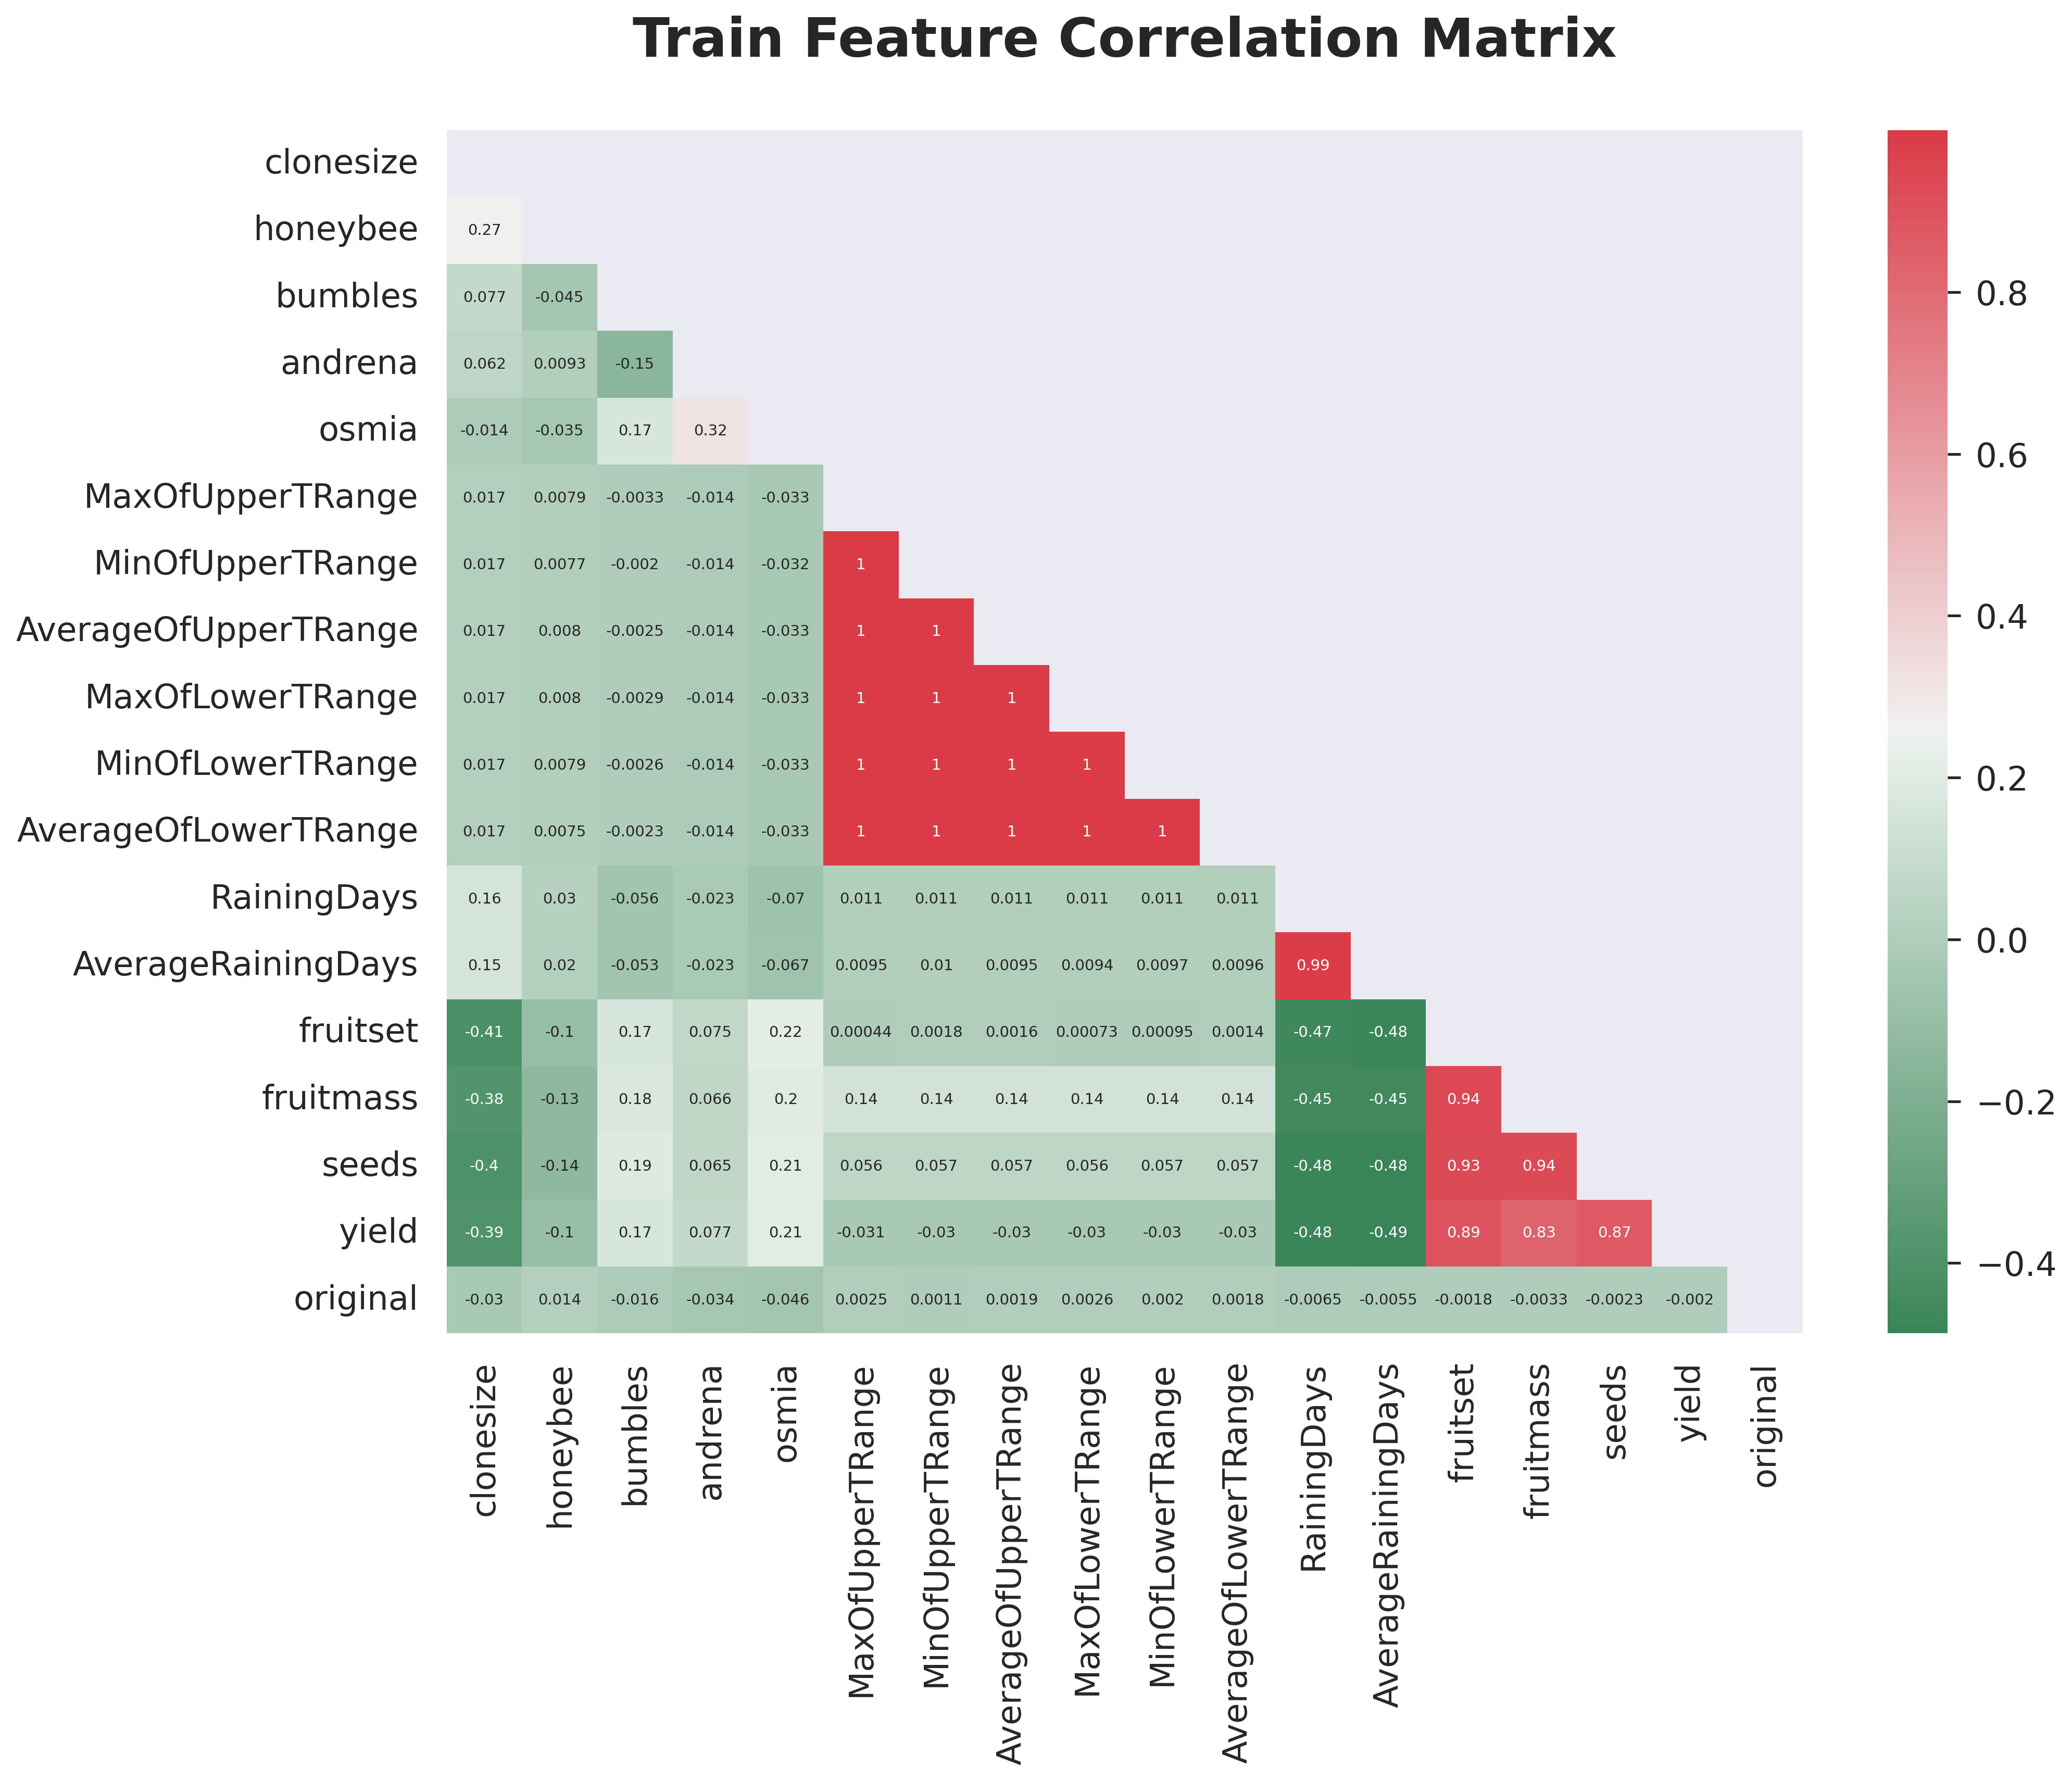

In [26]:
corr = train.corr()
plt.figure(figsize = (14, 10), dpi = 300)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask = mask, cmap = sns.diverging_palette(500, 10, as_cmap=True), annot = True, annot_kws = {'size' : 7})
plt.title('Train Feature Correlation Matrix\n', fontsize = 25, weight = 'bold')
plt.show()

<font size="3">Clearly, many of the features are highly correlated. 

<a id="4"></a>
# 4. Feature Engineering

# 4.1 Transformations

<font size="3">We're going to see what transformation works better for each feature and select them, the idea is to compress the data. There could be situations where you will have to stretch the data. These are the methods applied:</font>
<font size="3">
1. <font size="3">**Log Transformation**</font>: <font size="3">This transformation involves taking the logarithm of each data point. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = log(x)

2. <font size="3">**Square Root Transformation**</font>: <font size="3">This transformation involves taking the square root of each data point. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = sqrt(x)

3. <font size="3">**Box-Cox Transformation**</font>: <font size="3">This transformation is a family of power transformations that includes the log and square root transformations as special cases. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = [(x^lambda) - 1] / lambda if lambda != 0
                y = log(x) if lambda = 0

4. <font size="3">**Yeo-Johnson Transformation**</font>: <font size="3">This transformation is similar to the Box-Cox transformation, but it can be applied to both positive and negative values. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = [(|x|^lambda) - 1] / lambda if x >= 0, lambda != 0
                y = log(|x|) if x >= 0, lambda = 0
                y = -[(|x|^lambda) - 1] / lambda if x < 0, lambda != 2
                y = -log(|x|) if x < 0, lambda = 2

5. <font size="3">**Power Transformation**</font>: <font size="3">This transformation involves raising each data point to a power. It is useful when the data is highly skewed and the variance increases with the mean. The power can be any value, and is often determined using statistical methods such as the Box-Cox or Yeo-Johnson transformations.</font>
                y = [(x^lambda) - 1] / lambda if method = "box-cox" and lambda != 0
                y = log(x) if method = "box-cox" and lambda = 0
                y = [(x + 1)^lambda - 1] / lambda if method = "yeo-johnson" and x >= 0, lambda != 0
                y = log(x + 1) if method = "yeo-johnson" and x >= 0, lambda = 0
                y = [-(|x| + 1)^lambda - 1] / lambda if method = "yeo-johnson" and x < 0, lambda != 2
                y = -log(|x| + 1) if method = "yeo-johnson" and x < 0, lambda = 2

In [1]:
sc=MinMaxScaler()
unimportant_features=[]
table = PrettyTable()
dt_params= {'min_samples_split': 80, 'min_samples_leaf': 30, 'max_depth': 8, 'criterion': 'absolute_error'}

table.field_names = ['Original Feature', 'Original MAE(CV-TRAIN)', 'Transformed Feature', 'Tranformed MAE(CV-TRAIN)']
for col in cont_cols:
    
    # Log Transformation after MinMax Scaling(keeps data between 0 and 1)
    train["log_"+col]=np.log1p(sc.fit_transform(train[[col]]))
    test["log_"+col]=np.log1p(sc.transform(test[[col]]))
    
    # Square Root Transformation
    train["sqrt_"+col]=np.sqrt(sc.fit_transform(train[[col]]))
    test["sqrt_"+col]=np.sqrt(sc.transform(test[[col]]))
    
    # Box-Cox transformation
    transformer = PowerTransformer(method='box-cox')
    train["bx_cx_"+col] = transformer.fit_transform(sc.fit_transform(train[[col]])+1) # adjusted to make it +ve
    test["bx_cx_"+col] = transformer.transform(sc.transform(test[[col]])+1)
    
    # Yeo-Johnson transformation
    transformer = PowerTransformer(method='yeo-johnson')
    train["y_J_"+col] = transformer.fit_transform(train[[col]])
    test["y_J_"+col] = transformer.transform(test[[col]])
    
    # Power transformation, 0.25
    power_transform = lambda x: np.power(x, 0.25) 
    transformer = FunctionTransformer(power_transform)
    train["pow_"+col] = transformer.fit_transform(sc.fit_transform(train[[col]]))
    test["pow_"+col] = transformer.transform(sc.transform(test[[col]]))
    
    # Power transformation, 0.1
    power_transform = lambda x: np.power(x, 0.1) 
    transformer = FunctionTransformer(power_transform)
    train["pow2_"+col] = transformer.fit_transform(sc.fit_transform(train[[col]]))
    test["pow2_"+col] = transformer.transform(sc.transform(test[[col]]))
    
    # log to power transformation
    train["log_pow2"+col]=np.log1p(train["pow2_"+col])
    test["log_pow2"+col]=np.log1p(test["pow2_"+col])
    
    temp_cols=[col,"log_"+col,"sqrt_"+col, "bx_cx_"+col,"y_J_"+col ,"pow_"+col,"pow2_"+col,"log_pow2"+col ]
    
    #Apply PCA on  the features and compute an additional column
    pca=TruncatedSVD(n_components=1)
    x_pca_train=pca.fit_transform(train[temp_cols])
    x_pca_test=pca.transform(test[temp_cols])
    x_pca_train=pd.DataFrame(x_pca_train, columns=[col+"_pca_comb"])
    x_pca_test=pd.DataFrame(x_pca_test, columns=[col+"_pca_comb"])
    temp_cols.append(col+"_pca_comb")
    #print(temp_cols)
    
    train=pd.concat([train,x_pca_train],axis='columns')
    test=pd.concat([test,x_pca_test],axis='columns')
    
    # See which transformation along with the original is giving you the best univariate fit with target
    kf=KFold(n_splits=10, shuffle=True, random_state=42)
    
    MAE=[]
    
    for f in temp_cols:
        X=train[[f]].values
        y=train["yield"].values
        
        mae=[]
        for train_idx, val_idx in kf.split(X,y):
            X_train,y_train=X[train_idx],y[train_idx]
            x_val,y_val=X[val_idx],y[val_idx]
            
#             model=LinearRegression()
            model=DecisionTreeRegressor(**dt_params)
            model.fit(X_train,y_train)
            y_pred=model.predict(x_val)
            mae.append(mean_absolute_error(y_val,y_pred))
        MAE.append((f,np.mean(mae)))
        if f==col:
            orig_mae=np.mean(mae)
    best_col, best_acc=sorted(MAE, key=lambda x:x[1], reverse=False)[0]
    
    cols_to_drop = [f for f in temp_cols if  f!= best_col]
#     print(cols_to_drop)
    final_selection=[f for f in temp_cols if f not in cols_to_drop]
    if cols_to_drop:
        unimportant_features=unimportant_features+cols_to_drop
    table.add_row([col,orig_mae,best_col ,best_acc])
print(table)    

NameError: name 'MinMaxScaler' is not defined

<font size="3">**INSIGHTS:**</font>
1. <font size="3">I have applied log, sqrt, box-cox, yeo-johnson, power(0.25), power(0.1), log on all the aformentioned featrures followed by PCA on all the set of created features. In total, we have created 8 additional features for each original feature</font>
2. <font size="3">features **fruitset** and **fruitmass** have the original features performing well than transformed features when Linear Regression is used however, Decision Trees selected all log transformed features</font>
3. <font size="3">I have not dropped the features, but saved them as unimportant set. These can be used in the later stage to extract some information</font>

# 4.2 Discrete Features- Encoding

<font size="3">For each categorical variable, perform the following encoding techniques:</font>
1. <font size="3">**Count/Frequency Encoding**</font>: <font size="3">Count the number of occurrences of each category and replace the category with its log count.</font>
2. <font size="3">**Count Labeling**</font>: <font size="3">Assign a label to each category based on its count, with higher counts receiving higher labels.</font>
3. <font size="3"> **Target-Guided Mean Encoding**</font>: <font size="3">Rank the categories based on the mean of target column across each category</font>

<font size="3">Let's drop the features with correlation 1 before encoding them</font>

In [28]:
train["AverageTRange"]=(train["AverageOfUpperTRange"]+train["AverageOfLowerTRange"])/2
test["AverageTRange"]=(test["AverageOfUpperTRange"]+test["AverageOfLowerTRange"])/2

drop_temp_cols=["MaxOfUpperTRange","MinOfUpperTRange","MaxOfLowerTRange","MinOfLowerTRange","AverageOfUpperTRange","AverageOfLowerTRange"]
train.drop(columns=drop_temp_cols,inplace=True)
test.drop(columns=drop_temp_cols,inplace=True)

cat_features=[f for f in train.columns if f not in ["yield", "original"] and train[f].nunique()<=100]    

# 4.3 Pre-Encoding Clustering

1. <font size="3"> Let's do group clustering followed by a log transformed target mean encoding before we deal with individual feature</font>
2. <font size="3"> Since it is a regression problem, instead of compting the WOE, I'm just deriving a log transformation of Target Mean Encoding of the clusters</font>
3. <font size="3"> In the later stages of solving this problem, these categorical/discrete features came out to be unimportant. So, decided not to use the above mentioned methods.</font>

5
950.6740440637113


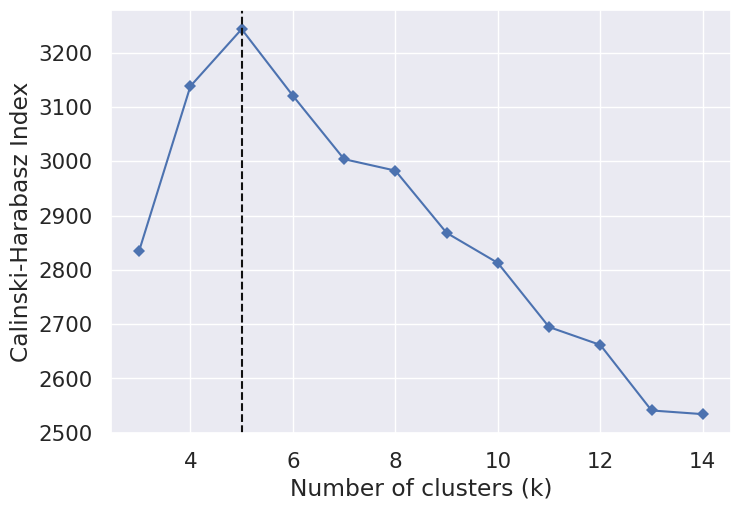

In [29]:
temp_train=train[cat_features]
temp_test=test[cat_features]
sc=StandardScaler()
temp_train=sc.fit_transform(temp_train)
temp_test=sc.transform(temp_test)
model = KMeans()


# Initialize the KElbowVisualizer with the KMeans model and desired range of clusters
visualizer = KElbowVisualizer(model, k=(3, 15), metric='calinski_harabasz', timings=False)

# Fit the visualizer to the data
visualizer.fit(np.array(temp_train))

ideal_clusters = visualizer.elbow_value_
plt.xlabel('Number of clusters (k)')
plt.ylabel('Calinski-Harabasz Index') 
print(ideal_clusters)
kmeans = KMeans(n_clusters=ideal_clusters)
kmeans.fit(np.array(temp_train))
labels_train = kmeans.labels_

train['cat_cluster_WOE'] = labels_train
test['cat_cluster_WOE'] = kmeans.predict(np.array(temp_test))

cat_labels=cat_labels=np.log1p(train.groupby(['cat_cluster_WOE'])['yield'].mean())
cat_labels2=cat_labels.to_dict()
train['cat_cluster_WOE']=train['cat_cluster_WOE'].map(cat_labels2)
test['cat_cluster_WOE']=test['cat_cluster_WOE'].map(cat_labels2)

X=train[['cat_cluster_WOE']].values
y=train["yield"].values

mae=[]
for train_idx, val_idx in kf.split(X,y):
    X_train,y_train=X[train_idx],y[train_idx]
    x_val,y_val=X[val_idx],y[val_idx]

    model=LinearRegression()
    model.fit(X_train,y_train)
    y_pred=model.predict(x_val)
    mae.append(mean_absolute_error(y_val,y_pred))
print(np.mean(mae))

In [30]:

# for feature in cat_features:
#     ## Target Guided Mean --Data Leakage Possible
    
#     cat_labels=train.groupby([feature])['yield'].mean().sort_values().index
#     cat_labels2={k:i for i,k in enumerate(cat_labels,0)}
#     train[feature+"_target"]=train[feature].map(cat_labels2)
#     test[feature+"_target"]=test[feature].map(cat_labels2)
    
#     ## Count Encoding
    
#     dic=train[feature].value_counts().to_dict()
#     train[feature+"_count"]=np.log1p(train[feature].map(dic))
#     test[feature+"_count"]=np.log1p(test[feature].map(dic))

    
#     ## Count Labeling
    
#     dic2=train[feature].value_counts().to_dict()
#     list1=np.arange(len(dic2.values()),0,-1) # Higher rank for high count
#     # list1=np.arange(len(dic2.values())) # Higher rank for low count
#     dic3=dict(zip(list(dic2.keys()),list1))
#     train[feature+"_count_label"]=train[feature].replace(dic3)
#     test[feature+"_count_label"]=test[feature].replace(dic3)
    
    
#     ## Clsuter Encoding
#     temp_train=train[[feature]]
#     temp_test=test[[feature]]
#     sc=StandardScaler()
#     temp_train=sc.fit_transform(temp_train)
#     temp_test=sc.transform(temp_test)
#     model = KMeans()

#     # Initialize the KElbowVisualizer with the KMeans model and desired range of clusters
#     visualizer = KElbowVisualizer(model, k=(5, 25), metric='calinski_harabasz', timings=False)

#     # Fit the visualizer to the data
#     visualizer.fit(np.array(temp_train).reshape(-1, 1))
    
#     ideal_clusters = visualizer.elbow_value_
    
#     if ideal_clusters is None:
#         ideal_clusters=25
#     print(f, ideal_clusters)
#     kmeans = KMeans(n_clusters=ideal_clusters)
#     kmeans.fit(np.array(temp_train))
#     labels_train = kmeans.labels_
    
#     train[feature+'_cluster_WOE'] = labels_train
#     test[feature+'_cluster_WOE'] = kmeans.predict(np.array(temp_test))
    
    
    
#     temp_cols=[feature+"_target", feature+"_count", feature+"_count_label",feature+'_cluster_WOE']
#     if train[feature].dtype!="O":
#         temp_cols.append(feature)
# #     else:
# #         train.drop(columns=[feature],inplace=True)
# #         test.drop(columns=[feature],inplace=True)
    
#     # See which transformation along with the original is giving you the best univariate fit with target
#     kf=KFold(n_splits=10, shuffle=True, random_state=42)
    
#     MAE=[]
    
#     for f in temp_cols:
#         X=train[[f]].values
#         y=train["yield"].values
        
#         mae=[]
#         for train_idx, val_idx in kf.split(X,y):
#             X_train,y_train=X[train_idx],y[train_idx]
#             x_val,y_val=X[val_idx],y[val_idx]
            
#             model=LinearRegression()
#             model.fit(X_train,y_train)
#             y_pred=model.predict(x_val)
#             mae.append(mean_absolute_error(y_val,y_pred))
#         MAE.append((f,np.mean(mae)))
#     best_col, best_acc=sorted(MAE, key=lambda x:x[1], reverse=False)[0]
    
#     # check correlation between best_col and other columns and drop if correlation >0.75
#     corr = train[temp_cols].corr(method='pearson')
#     corr_with_best_col = corr[best_col]
#     cols_to_drop = [f for f in temp_cols if corr_with_best_col[f] > 0.3 and f != best_col]
#     final_selection=[f for f in temp_cols if f not in cols_to_drop]
#     if cols_to_drop:
#         train = train.drop(columns=cols_to_drop)
#         test = test.drop(columns=cols_to_drop)
    
#     print(col,final_selection,best_acc)

# 4.4 Clustering-One Hot Transformation

<font size="3">Let's take the unimportant feartures we created using transformations and use them to create clusters followed by a one hot encoding on them. We wil apply this on each subset of original features</font>

['fruitset', 'log_fruitset', 'sqrt_fruitset', 'bx_cx_fruitset', 'y_J_fruitset', 'pow2_fruitset', 'log_pow2fruitset', 'fruitset_pca_comb']


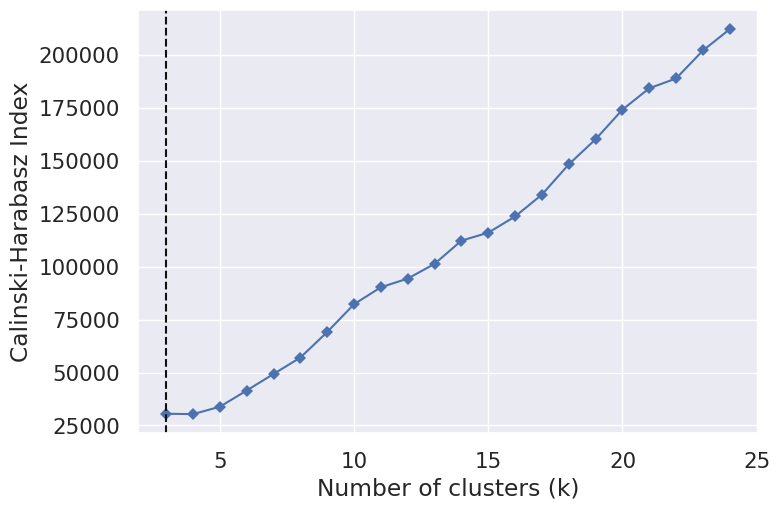

['fruitmass', 'log_fruitmass', 'sqrt_fruitmass', 'bx_cx_fruitmass', 'y_J_fruitmass', 'pow_fruitmass', 'log_pow2fruitmass', 'fruitmass_pca_comb']


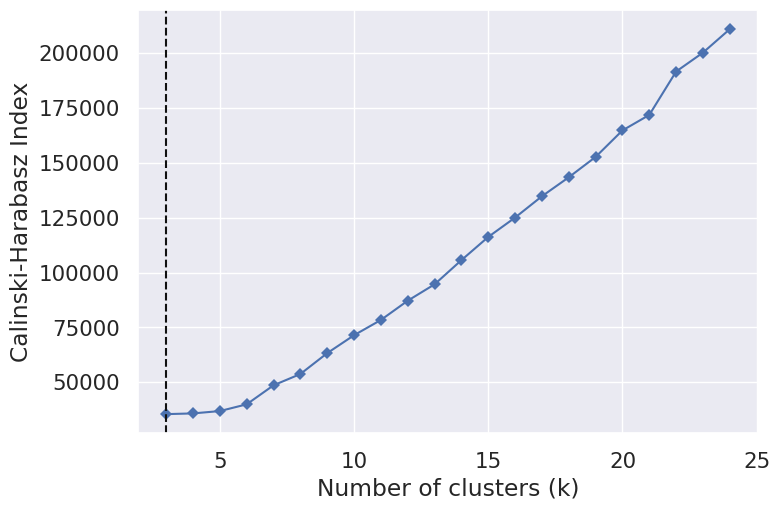

['seeds', 'log_seeds', 'sqrt_seeds', 'bx_cx_seeds', 'y_J_seeds', 'pow_seeds', 'pow2_seeds', 'seeds_pca_comb']


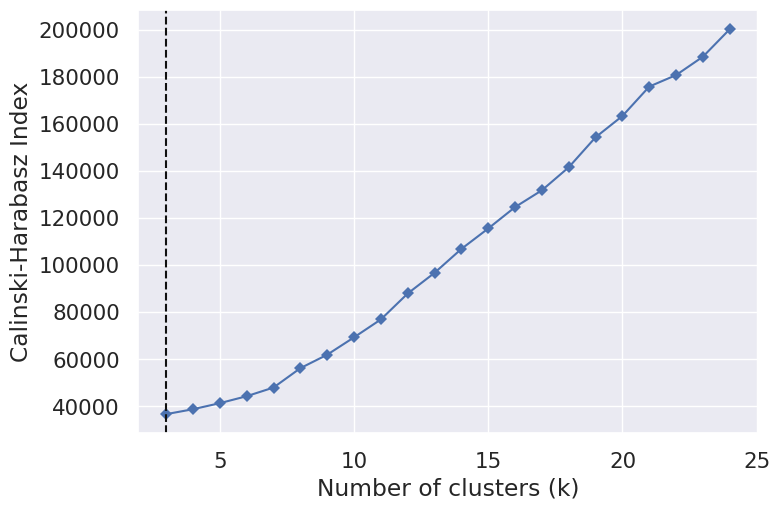

+-----------------------------+-------------------+
|     Cluster WOE Feature     |   MAE(CV-TRAIN)   |
+-----------------------------+-------------------+
|  fruitset_unimp_cluster_WOE | 581.1074845550374 |
| fruitmass_unimp_cluster_WOE | 658.9063312375949 |
|   seeds_unimp_cluster_WOE   | 598.3252885194472 |
+-----------------------------+-------------------+


In [31]:
def OHE(train,test,cols,target):
    combined = pd.concat([train, test], axis=0)
    for col in cols:
        one_hot = pd.get_dummies(combined[col])
        counts = combined[col].value_counts()
        min_count_category = counts.idxmin()
        one_hot = one_hot.drop(min_count_category, axis=1)
        combined = pd.concat([combined, one_hot], axis="columns")
        combined = combined.drop(col, axis=1)
        combined = combined.loc[:, ~combined.columns.duplicated()]
    
    # split back to train and test dataframes
    train_ohe = combined[:len(train)]
    test_ohe = combined[len(train):]
    test_ohe.reset_index(inplace=True,drop=True)
    test_ohe.drop(columns=[target],inplace=True)
    
    return train_ohe, test_ohe

table = PrettyTable()
table.field_names = ['Cluster WOE Feature', 'MAE(CV-TRAIN)']
for col in cont_cols:
    sub_set=[f for f in unimportant_features if col in f]
    print(sub_set)
    temp_train=train[sub_set]
    temp_test=test[sub_set]
    sc=StandardScaler()
    temp_train=sc.fit_transform(temp_train)
    temp_test=sc.transform(temp_test)
    model = KMeans()


    # Initialize the KElbowVisualizer with the KMeans model and desired range of clusters
    visualizer = KElbowVisualizer(model, k=(3, 25), metric='calinski_harabasz', timings=False)

    # Fit the visualizer to the data
    visualizer.fit(np.array(temp_train))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Calinski-Harabasz Index')
    plt.show()

    ideal_clusters = visualizer.elbow_value_

    # print(ideal_clusters)
    kmeans = KMeans(n_clusters=ideal_clusters)
    kmeans.fit(np.array(temp_train))
    labels_train = kmeans.labels_

    train[col+'_OHE_cluster'] = labels_train
    test[col+'_OHE_cluster'] = kmeans.predict(np.array(temp_test))
    # Also, making a copy to do mean encoding followed by a log transformation
    
    train[col+"_unimp_cluster_WOE"]=train[col+'_OHE_cluster']
    test[col+"_unimp_cluster_WOE"]=test[col+'_OHE_cluster'] 
    cat_labels=cat_labels=np.log1p(train.groupby([col+"_unimp_cluster_WOE"])['yield'].mean())
    cat_labels2=cat_labels.to_dict()
    train[col+"_unimp_cluster_WOE"]=train[col+"_unimp_cluster_WOE"].map(cat_labels2)
    test[col+"_unimp_cluster_WOE"]=test[col+"_unimp_cluster_WOE"].map(cat_labels2)

    X=train[[col+"_unimp_cluster_WOE"]].values
    y=train["yield"].values

    mae=[]
    for train_idx, val_idx in kf.split(X,y):
        X_train,y_train=X[train_idx],y[train_idx]
        x_val,y_val=X[val_idx],y[val_idx]

        model=LinearRegression()
        model.fit(X_train,y_train)
        y_pred=model.predict(x_val)
        mae.append(mean_absolute_error(y_val,y_pred))
    table.add_row([col+"_unimp_cluster_WOE",np.mean(mae)])
    
    train[col+'_OHE_cluster']=col+"_OHE_"+train[col+'_OHE_cluster'].astype(str)
    test[col+'_OHE_cluster']=col+"_OHE_"+test[col+'_OHE_cluster'].astype(str)
    train, test=OHE(train,test,[col+'_OHE_cluster'],"yield")
print(table)

# 4.5 Multiplicative Features

<font size="3">In this section, a new product feature if created on by multiplying all continuous features. The final selection of features depend on the MAE values with a cutoff</font>

In [32]:
from itertools import combinations
num_features=[f for f in train.columns if train[f].nunique()>100 and f not in ['yield']]
feature_pairs = list(combinations(cont_cols, 2))

table = PrettyTable()
table.field_names = ['Pair Features', 'MAE(CV-TRAIN)', "Selected"]

dt_params= {'min_samples_split': 80, 'min_samples_leaf': 30, 'max_depth': 8, 'criterion': 'absolute_error'}

selected_features=[]
max_product=float('-inf')
for pair in feature_pairs:
    col1, col2 = pair
#     print(pair)
    product_col_train = train[col1] * train[col2]
    product_col_test= test[col1] * test[col2]
    name=f'{col1}_{col2}_product'
    train[name] = product_col_train
    test[name] = product_col_test
    max_product = max(max_product, product_col_train.max())

    kf=KFold(n_splits=5, shuffle=True, random_state=42)
    MAE=[]
    X=train[[name]].values
    y=train["yield"].values

    mae=[]
    for train_idx, val_idx in kf.split(X,y):
        X_train,y_train=X[train_idx],y[train_idx]
        x_val,y_val=X[val_idx],y[val_idx]

        model=LinearRegression()
#         model=DecisionTreeRegressor(**dt_params)
        model.fit(X_train,y_train)
        y_pred=model.predict(x_val)
        mae.append(mean_absolute_error(y_val,y_pred))
    if np.mean(mae)>400:
        unimportant_features.append(name)
        selected="No"
    else:
        selected_features.append(pair)
        selected="Yes"
    table.add_row([pair,np.mean(mae),selected ])
table.sortby = 'MAE(CV-TRAIN)'
table.reversesort = False
print(table)

+---------------------------+--------------------+----------+
|       Pair Features       |   MAE(CV-TRAIN)    | Selected |
+---------------------------+--------------------+----------+
|   ('fruitset', 'seeds')   | 394.17876692614954 |   Yes    |
| ('fruitset', 'fruitmass') | 422.8767081615636  |    No    |
|   ('fruitmass', 'seeds')  | 463.2894687709246  |    No    |
+---------------------------+--------------------+----------+


# 4.6 Unimportant Features

<font size="3">There are lot of features that are unimportant, the first level of reduction is to create subsets based on the original features, apply PCA to select PC1 and drop the subset</font>

In [33]:
for col in cont_cols:
    sub_set=[f for f in unimportant_features if col in f]
    
    existing=[f for f in train.columns if f in sub_set]
    temp_train=train[existing]
    temp_test=test[existing]
    sc=StandardScaler()
    temp_train=sc.fit_transform(temp_train)
    temp_test=sc.transform(temp_test)
    
    pca=TruncatedSVD(n_components=1)
    x_pca_train=pca.fit_transform(temp_train)
    x_pca_test=pca.transform(temp_test)
    x_pca_train=pd.DataFrame(x_pca_train, columns=[col+"_pca_comb_unimp"])
    x_pca_test=pd.DataFrame(x_pca_test, columns=[col+"_pca_comb_unimp"])
    
    train=pd.concat([train,x_pca_train],axis='columns')
    test=pd.concat([test,x_pca_test],axis='columns')
    for f in sub_set:
        if f in train.columns and f not in cont_cols:
            train=train.drop(columns=[f])
            test=test.drop(columns=[f])

<font size="3">Finally, we have reduced the features. However, we're going to see a some correlated features since all these features are created from a few original features</font>

# 4.7 Feature Selection

In [34]:
# To further eliminate features, let's split the features into two sets
fruit_features=[f for f in train.columns if 'fruit' in f or 'seed' in f]
non_fruit_features=[f for f in train.columns if f not in fruit_features+['yield']]

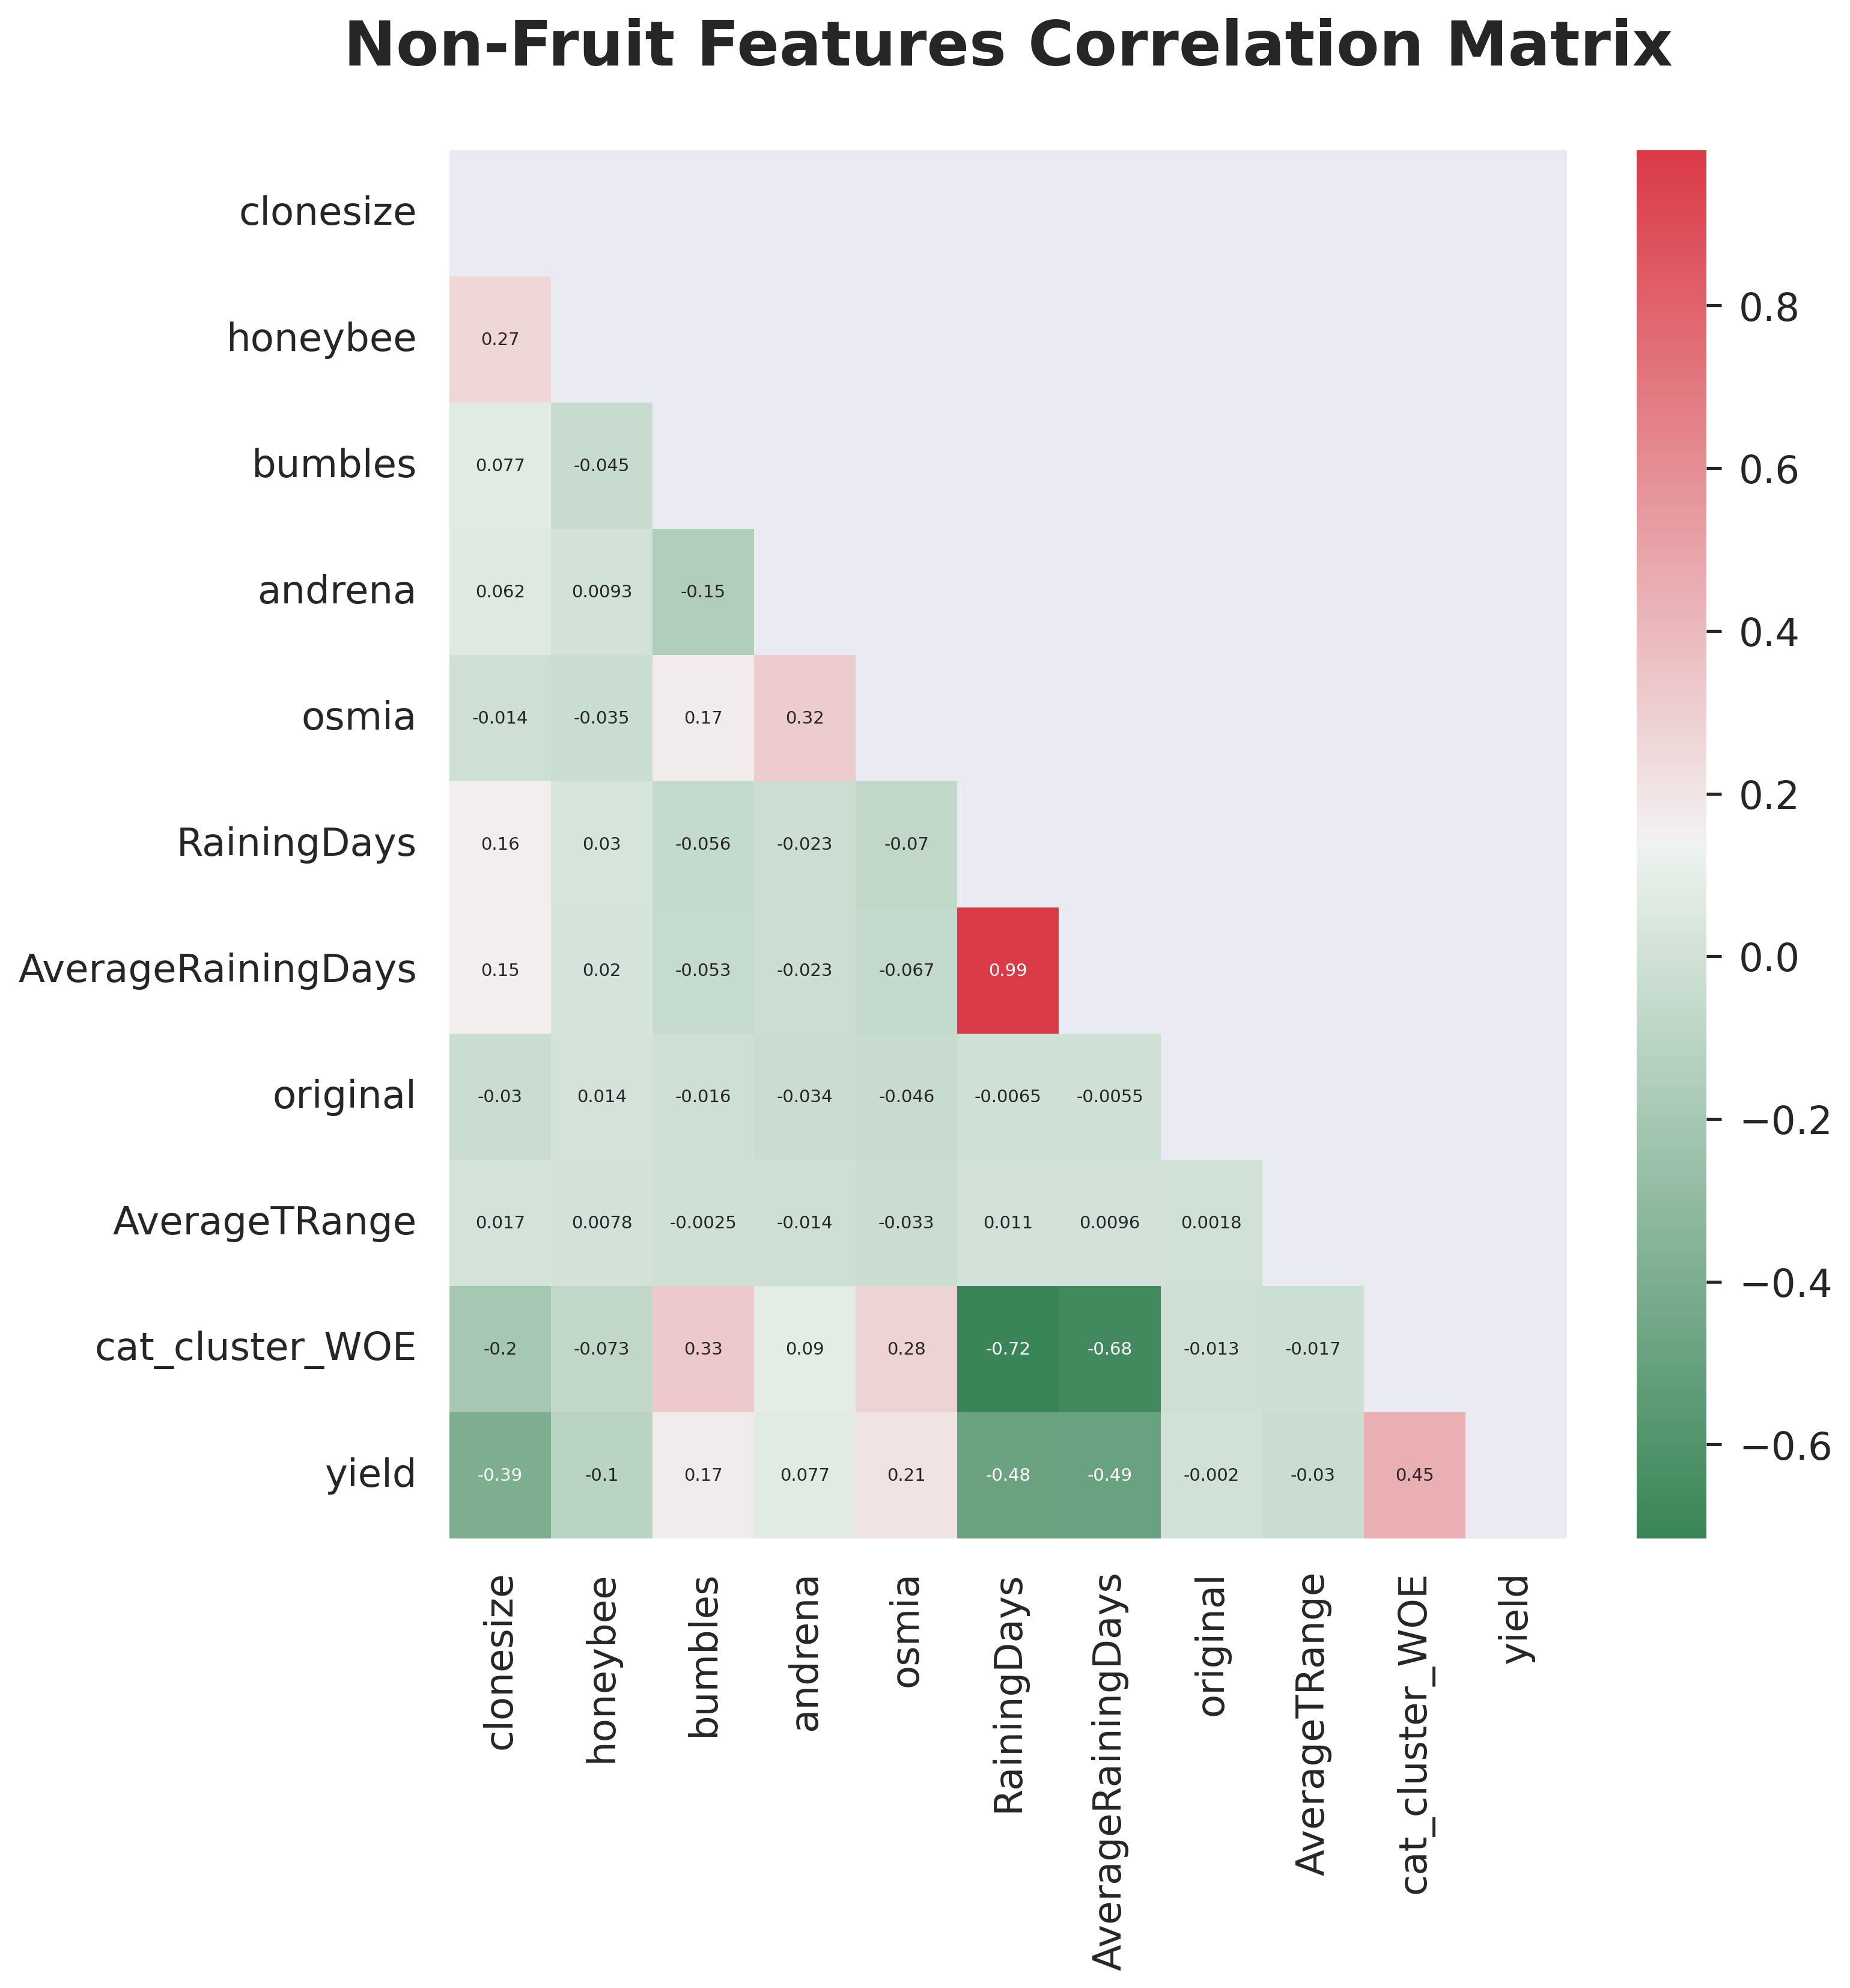

In [35]:
corr = train[non_fruit_features+["yield"]].corr()
plt.figure(figsize = (10, 10), dpi = 300)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask = mask, cmap = sns.diverging_palette(500, 10, as_cmap=True), annot = True, annot_kws = {'size' : 7})
plt.title('Non-Fruit Features Correlation Matrix\n', fontsize = 25, weight = 'bold')
plt.show()

<font size="3"> Based on the above matrix, dopping one of the highly correlated features. Not resorting to PCA on these columns as their correlarion with target is low.</font>

In [36]:
train.drop(columns=['RainingDays'],inplace=True)
test.drop(columns=['RainingDays'],inplace=True)

In [ ]:
corr = train[fruit_features+["yield"]].corr()
plt.figure(figsize = (30, 30), dpi = 300)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask = mask, cmap = sns.diverging_palette(500, 10, as_cmap=True), annot = True, annot_kws = {'size' : 14})
plt.title('Fruit Features Correlation Matrix\n', fontsize = 29, weight = 'bold')
plt.show()

<font size="3">The possible reason why we see a lot of features with correlation 1 is that we had applied PCA on two levels during transformation phase and then elimination phase.</font>

**Steps to Eliminate Correlated Fruit Features**:
1. <font size="3">Group features based on their parent feature. For example, all features derived from fruitset come under one set</font>
2. <font size="3">Apply PCA on the set, Cluster-Target Encoding on the set</font>
3. <font size="3">See the performance of each feature on a cross-validated single feature-target model</font>
4. <font size="3">Select the feature with highest CV-MAE</font>

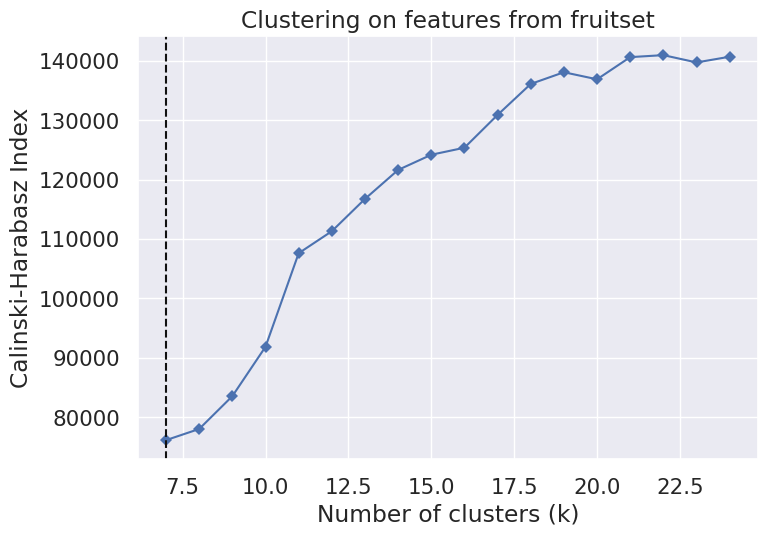

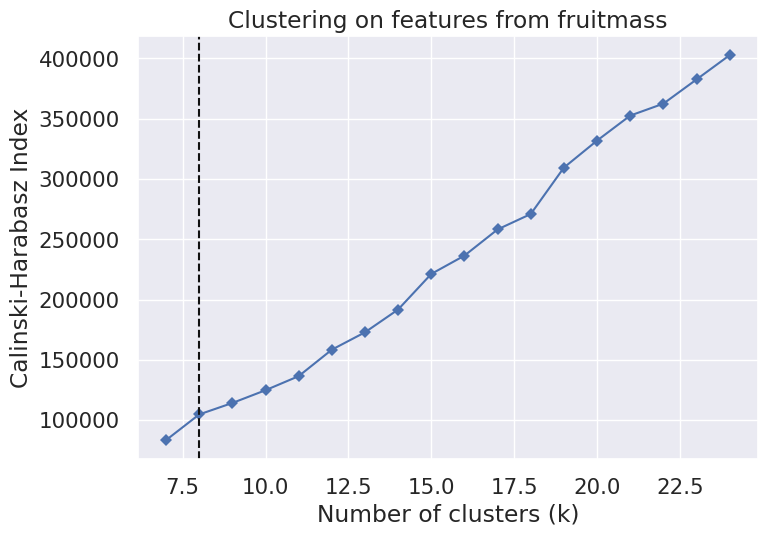

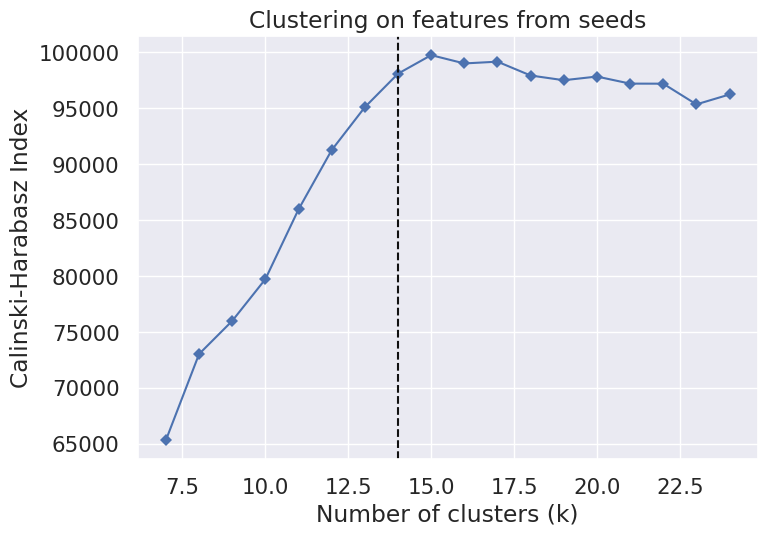

+-----------+---------------------------+---------------------+
|  Original | Final Transformed feature | MAE(CV)- Regression |
+-----------+---------------------------+---------------------+
|  fruitset |  fruitset_pca_comb_final  |  361.5976696817656  |
| fruitmass |  fruitmass_pca_comb_final |  486.6102020169707  |
|   seeds   |   fruitset_seeds_product  |  365.94269659442523 |
+-----------+---------------------------+---------------------+


In [38]:
final_drop_list=[]

table = PrettyTable()
table.field_names = ['Original', 'Final Transformed feature', "MAE(CV)- Regression"]

threshold=0.7
# It is possible that multiple parent features share same child features, so storing selected features to avoid selecting the same feature again
best_cols=[]

for col in cont_cols:
    sub_set=[f for f in fruit_features if col in f]
    # print(sub_set)
    
    correlated_features = []

    # Loop through each feature
    for i, feature in enumerate(sub_set):
        # Check correlation with all remaining features
        for j in range(i+1, len(sub_set)):
            correlation = np.abs(train[feature].corr(train[sub_set[j]]))
            # If correlation is greater than threshold, add to list of highly correlated features
            if correlation > threshold:
                correlated_features.append(sub_set[j])

    # Remove duplicate features from the list
    correlated_features = list(set(correlated_features))

    temp_train=train[correlated_features]
    temp_test=test[correlated_features]
    #Scale before applying PCA
    sc=StandardScaler()
    temp_train=sc.fit_transform(temp_train)
    temp_test=sc.transform(temp_test)
    
    # Initiate PCA
    pca=TruncatedSVD(n_components=1)
    x_pca_train=pca.fit_transform(temp_train)
    x_pca_test=pca.transform(temp_test)
    x_pca_train=pd.DataFrame(x_pca_train, columns=[col+"_pca_comb_final"])
    x_pca_test=pd.DataFrame(x_pca_test, columns=[col+"_pca_comb_final"])
    train=pd.concat([train,x_pca_train],axis='columns')
    test=pd.concat([test,x_pca_test],axis='columns')
    
    # Clustering
    model = KMeans()


    # Initialize the KElbowVisualizer with the KMeans model and desired range of clusters
    visualizer = KElbowVisualizer(model, k=(7, 25), metric='calinski_harabasz', timings=False)

    # Fit the visualizer to the data
    visualizer.fit(np.array(temp_train))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Calinski-Harabasz Index')
    plt.title("Clustering on features from "+col)
    plt.show()

    ideal_clusters = visualizer.elbow_value_

    # print(ideal_clusters)
    kmeans = KMeans(n_clusters=ideal_clusters)
    kmeans.fit(np.array(temp_train))
    labels_train = kmeans.labels_

    train[col+'_final_cluster'] = labels_train
    test[col+'_final_cluster'] = kmeans.predict(np.array(temp_test))

    cat_labels=cat_labels=np.log1p(train.groupby([col+"_final_cluster"])['yield'].mean())
    cat_labels2=cat_labels.to_dict()
    train[col+"_final_cluster"]=train[col+"_final_cluster"].map(cat_labels2)
    test[col+"_final_cluster"]=test[col+"_final_cluster"].map(cat_labels2)

    correlated_features=correlated_features+[col+"_pca_comb_final",col+"_final_cluster"]
    
    # See which transformation along with the original is giving you the best univariate fit with target
    kf=KFold(n_splits=5, shuffle=True, random_state=42)
    
    MAE=[]
    
    for f in correlated_features:
        X=train[[f]].values
        y=train["yield"].values
        
        mae=[]
        for train_idx, val_idx in kf.split(X,y):
            X_train,y_train=X[train_idx],y[train_idx]
            x_val,y_val=X[val_idx],y[val_idx]
            
#             model=LinearRegression()
            model=DecisionTreeRegressor(**dt_params)
            model.fit(X_train,y_train)
            y_pred=model.predict(x_val)
            mae.append(mean_absolute_error(y_val,y_pred))
        if f not in best_cols:
            MAE.append((f,np.mean(mae)))
    best_col, best_acc=sorted(MAE, key=lambda x:x[1], reverse=False)[0]
    best_cols.append(best_col)
    
    cols_to_drop = [f for f in correlated_features if  f not in best_cols]
    if cols_to_drop:
        final_drop_list=final_drop_list+cols_to_drop
    table.add_row([col,best_col ,best_acc])

print(table)      

In [39]:
final_drop_list=[f for f in final_drop_list if f not in cont_cols]
train.drop(columns=[*set(final_drop_list)],inplace=True)
test.drop(columns=[*set(final_drop_list)],inplace=True)

<a id="5"></a>
# 5. Scaling the Data

In [40]:
# These features are dropped from feature importance of LightGBM, RandormForests
drop_list=[f for f in  train.columns if "OHE" in f and "fruit" in f]
train=train.drop(columns=drop_list)
test=test.drop(columns=drop_list)

In [41]:
feature_scale=[feature for feature in train.columns if feature not in ['yield']]

scaler=StandardScaler()

train[feature_scale]=scaler.fit_transform(train[feature_scale])
test[feature_scale]=scaler.transform(test[feature_scale])

X_train=train.drop(['yield'],axis=1)
# y_train=np.log1p(train['yield'])
y_train=train['yield']

X_test=test.copy()

print(X_train.shape,X_test.shape)

(16066, 15) (10194, 15)


# 6. Modeling

In [42]:
import tensorflow
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

In [75]:
from keras import backend as K
def mean_abs_error(y_true, y_pred):
        return K.mean(K.abs(y_pred - y_true))

sgd=tensorflow.keras.optimizers.SGD(learning_rate=0.01,momentum=0.1, nesterov=True)
rms = tensorflow.keras.optimizers.RMSprop()
nadam=tensorflow.keras.optimizers.Nadam(
    learning_rate=0.01, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name="Nadam"
)
lrelu = lambda x: tensorflow.keras.activations.relu(x, alpha=0.1)

ann = Sequential()
ann.add(Dense(32, input_dim=X_train.shape[1], kernel_initializer='he_uniform', activation="relu"))
# ann.add(Dense(64,  kernel_initializer='he_uniform', activation='relu'))
# ann.add(Dropout(0.5))
ann.add(Dense(128,  kernel_initializer='he_uniform', activation='relu'))
ann.add(Dropout(0.6))
ann.add(Dense(64,  kernel_initializer='he_uniform', activation="relu"))
ann.add(Dropout(0.5))
ann.add(Dense(2,  kernel_initializer='he_uniform', activation="relu"))
ann.add(Dropout(0.1))
ann.add(Dense(1, kernel_initializer = 'he_uniform'))

ann.compile(loss=mean_abs_error, optimizer=nadam)

In [76]:
# ann.fit(X_train, y_train, validation_split=0.2,batch_size=2, epochs=40,verbose=1)

<font size="3">Kudos to tetsu2131( [http://www.kaggle.com/tetsutani]()) for this framework, the below parts of the code has been taken and modified from. Please support the account if you like this work.</font>

## 6.1 Model Selection

In [43]:
class Splitter:
    def __init__(self, test_size=0.2, kfold=True, n_splits=5):
        self.test_size = test_size
        self.kfold = kfold
        self.n_splits = n_splits

    def split_data(self, X, y, random_state_list):
        if self.kfold:
            for random_state in random_state_list:
                kf = KFold(n_splits=self.n_splits, random_state=random_state, shuffle=True)
                for train_index, val_index in kf.split(X, y):
                    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
                    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
                    yield X_train, X_val, y_train, y_val
        else:
            for random_state in random_state_list:
                X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=self.test_size, random_state=random_state)
                yield X_train, X_val, y_train, y_val

class Regressor:
    def __init__(self, n_estimators=100, device="gpu", random_state=0):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.reg_models = self._define_reg_model()
        self.len_models = len(self.reg_models)
        
    def _define_reg_model(self):
        
        xgb_params = {
            'n_estimators': self.n_estimators,
            'max_depth': 6,
            'learning_rate': 0.0116,
            'colsample_bytree': 1,
            'subsample': 0.6085,
            'min_child_weight': 9,
            'reg_lambda': 4.879e-07,
            'max_bin': 431,
            #'booster': 'dart',
            'n_jobs': -1,
            'eval_metric': 'mae',
            'objective': "reg:squarederror",
            #'tree_method': 'hist',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        if self.device == 'gpu':
            xgb_params['tree_method'] = 'gpu_hist'
            xgb_params['predictor'] = 'gpu_predictor'
        
        xgb_params1=xgb_params.copy()
        xgb_params1['subsample']=0.3
        xgb_params1['max_depth']=7
        xgb_params1['learning_rate']=0.01
        xgb_params1['colsample_bytree']=0.5

        xgb_params2=xgb_params.copy()
        xgb_params2['subsample']=0.5
        xgb_params2['max_depth']=6
        xgb_params2['learning_rate']=0.047
        xgb_params2['colsample_bytree']=0.9
        xgb_params2['tree_method']='approx'

        lgb_params = {
            'n_estimators': self.n_estimators,
            'max_depth': 8,
            "num_leaves": 16,
            'learning_rate': 0.05,
            'subsample': 0.7,
            'colsample_bytree': 0.8,
            #'reg_alpha': 0.25,
            'reg_lambda': 5e-07,
            'objective': 'regression_l1',
            'metric': 'mean_absolute_error',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state
        }
        
        lgb_params1=lgb_params.copy()
        lgb_params1['num_leaves']=90
        lgb_params1['reg_lambda']=0.015589408048174165
        lgb_params1['reg_alpha']=0.09765625
        lgb_params1['min_child_samples']=40
        lgb_params1['learning_rate']=0.01533790147941807
        lgb_params1['colsample_bytree']=0.8809128870084636

        lgb_params2=lgb_params.copy()
        lgb_params2['subsample']=0.3
        lgb_params2['reg_lambda']=5e-07
#         lgb_params2['reg_alpha']=0.4300477974434703
        lgb_params2['max_depth']=10
        lgb_params2['learning_rate']=0.019000000000000003
        lgb_params2['colsample_bytree']=0.8
        lgb_params3 = {
            'n_estimators': self.n_estimators,
            'num_leaves': 45,
            'max_depth': 13,
            'learning_rate': 0.0684383311038932,
            'subsample': 0.5758412171285148,
            'colsample_bytree': 0.8599714680300794,
            'reg_lambda': 1.597717830931487e-08,
            'objective': 'regression_l1',
            'metric': 'mean_absolute_error',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state,
            'verbosity': 0,
            'force_col_wise': True
        }
        lgb_params4=lgb_params.copy()
        lgb_params4['subsample']=0.3
        lgb_params4['reg_lambda']=0.1355199957045592
        lgb_params4['reg_alpha']=0.8414930901189801
        lgb_params4['max_depth']=10
        lgb_params4['learning_rate']=0.019000000000000003
        lgb_params4['colsample_bytree']=0.8

        cb_params = {
            'iterations': self.n_estimators,
            'depth': 6,
            'learning_rate': 0.02,
            'l2_leaf_reg': 0.5,
            'random_strength': 0.2,
            'max_bin': 150,
            'od_wait': 80,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'IncToDec',
            'eval_metric': 'MAE',
            'loss_function': 'MAE',
            'task_type': self.device.upper(),
            'random_state': self.random_state
        }
        cb_sym_params = cb_params.copy()
        cb_sym_params['grow_policy'] = 'SymmetricTree'
#         cb_loss_params = cb_params.copy()
#         cb_loss_params['grow_policy'] = 'Lossguide'
    
        cb_params1 = {
            'n_estimators': self.n_estimators,
            'depth': 10,
            'learning_rate': 0.08827842054729117,
            'l2_leaf_reg': 4.8351074756668864e-05,
            'random_strength': 0.21306687539993183,
            'max_bin': 483,
            'od_wait': 97,
            'grow_policy': 'Lossguide',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'MAE',
            'loss_function': 'MAE',
            'task_type': self.device.upper(),
            'random_state': self.random_state,
            'silent': True
        }
        cb_params2= {
            'n_estimators': self.n_estimators,
            'depth': 9,
            'learning_rate': 0.01,
            'l2_leaf_reg': 4.8351074756668864e-05,
            'random_strength': 0.21306687539993183,
            'max_bin': 225,
            'od_wait': 97,
            'grow_policy': 'Lossguide',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'MAE',
            'loss_function': 'MAE',
            'task_type': self.device.upper(),
            'random_state': self.random_state,
            'silent': True
        }
        cb_loss_params={
            'iterations': self.n_estimators,
            'depth': 8,
            'learning_rate': 0.01,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'max_bin': 200,
            'od_wait': 65,
            'one_hot_max_size': 70,
            'grow_policy': 'Lossguide',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'MAE',
            'loss_function': 'MAE',
            'task_type': self.device.upper(),
            'random_state': self.random_state
        }
        dt_params= {'min_samples_split': 80, 'min_samples_leaf': 30, 'max_depth': 8, 'criterion': 'absolute_error'}
        knn_params= {'weights': 'uniform', 'p': 1, 'n_neighbors': 12, 'leaf_size': 20, 'algorithm': 'kd_tree'}

        reg_models = {
#             'xgb_reg': xgb.XGBRegressor(**xgb_params),
#             'xgb_reg1': xgb.XGBRegressor(**xgb_params1),
#             'xgb_reg2': xgb.XGBRegressor(**xgb_params2),
            'lgb_reg': lgb.LGBMRegressor(**lgb_params),
#             'lgb2_reg': lgb.LGBMRegressor(**lgb_params1),
            'lgb3_reg': lgb.LGBMRegressor(**lgb_params2),
#             'lgb4_reg': lgb.LGBMRegressor(**lgb_params3),
#             'lgb5_reg': lgb.LGBMRegressor(**lgb_params4),
            "hgbm": HistGradientBoostingRegressor(max_iter=self.n_estimators, learning_rate=0.01, loss="absolute_error", 
                                                  n_iter_no_change=300,random_state=self.random_state),
            'cat_reg': CatBoostRegressor(**cb_params),
            'cat_reg2': CatBoostRegressor(**cb_params1),
            'cat_reg3': CatBoostRegressor(**cb_params2),
#             "cat_sym": CatBoostRegressor(**cb_sym_params),
            "cat_loss": CatBoostRegressor(**cb_loss_params),
            'etr': ExtraTreesRegressor(min_samples_split=55, min_samples_leaf= 15, max_depth=10,
                                       n_estimators=200,random_state=self.random_state),
#             'ann':ann,
            "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=2000, learning_rate=0.1, max_depth=6,loss="absolute_error", random_state=self.random_state),
            "RandomForestRegressor": RandomForestRegressor(max_depth= 9,max_features= 'auto',min_samples_split= 4,
                                                           min_samples_leaf= 4,  n_estimators=500, random_state=self.random_state, n_jobs=-1),
            'dt': DecisionTreeRegressor(**dt_params),
            
            "lr":LinearRegression(),
            "knn":KNeighborsRegressor(**knn_params),
            "PassiveAggressiveRegressor": PassiveAggressiveRegressor(max_iter=3000, tol=1e-3, n_iter_no_change=30, random_state=self.random_state),
            "HuberRegressor": HuberRegressor(max_iter=3000),

            
            
            
        }


        return reg_models

## 6.2 Weighted Ensembling

In [44]:
class OptunaWeights:
    def __init__(self, random_state):
        self.study = None
        self.weights = None
        self.random_state = random_state

    def _objective(self, trial, y_true, y_preds):
        # Define the weights for the predictions from each model
        weights = [trial.suggest_float(f"weight{n}", 0, 1) for n in range(len(y_preds))]

        # Calculate the weighted prediction
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=weights)

        # Calculate the MAE score for the weighted prediction
        score = mean_absolute_error(y_true, weighted_pred)
        return score

    def fit(self, y_true, y_preds, n_trials=300):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        self.study = optuna.create_study(sampler=sampler, study_name="OptunaWeights", direction='minimize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=n_trials)
        self.weights = [self.study.best_params[f"weight{n}"] for n in range(len(y_preds))]

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error, must be fitted before predict'
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=self.weights)
        return weighted_pred

    def fit_predict(self, y_true, y_preds, n_trials=300):
        self.fit(y_true, y_preds, n_trials=n_trials)
        return self.predict(y_preds)
    
    def weights(self):
        return self.weights

In [45]:
unique_targets = np.unique(train["yield"])

In [ ]:
kfold = True
n_splits = 1 if not kfold else 5
random_state = 42
random_state_list = [42] 
n_estimators = 9999 
early_stopping_rounds = 900
verbose = False
device = 'cpu'

splitter = Splitter(kfold=kfold, n_splits=n_splits)


# Initialize an array for storing test predictions
test_predss = np.zeros(X_test.shape[0])
ensemble_score = []
weights = []
trained_models = dict(zip(Regressor().reg_models.keys(), [[] for _ in range(Regressor().len_models)]))
trained_models = {'lgb_reg':[], 'cat_reg':[],"RandomForestRegressor":[]}

# Evaluate on validation data and store predictions on test data
for i, (X_train_, X_val, y_train_, y_val) in enumerate(splitter.split_data(X_train, y_train, random_state_list=random_state_list)):
    n = i % n_splits
    m = i // n_splits

    # Get a set of Regressor models
    reg = Regressor(n_estimators, device, random_state)
    models = reg.reg_models

    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []

    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        if ('cat' in name) or ("lgb" in name) or ("xgb" in name):
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name=='hgbm':
            model.fit(X_train_, y_train_)
        elif name=='ann':
            model.fit(X_train_, y_train_, validation_data=(X_val, y_val),batch_size=2, epochs=60,verbose=verbose)
        else:
            model.fit(X_train_, y_train_)
        if name=="ann":
            y_val_pred = model.predict(X_val)[:,0]
            test_pred = model.predict(X_test)[:,0]
        else:
            y_val_pred = model.predict(X_val)
            test_pred = model.predict(X_test)

        

#         # Convert predicted values back to their original scale by applying the expm1 function
#         y_val_pred = np.expm1(y_val_pred)
#         test_pred = np.expm1(test_pred)

        score = mean_absolute_error(y_val, y_val_pred)
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] MAE score: {score:.5f}')

        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
        if name in trained_models.keys():
            trained_models[f'{name}'].append(deepcopy(model))

    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state)
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)
    score = mean_absolute_error(y_val, y_val_pred)
    print(f'Ensemble [FOLD-{n} SEED-{random_state_list[m]}] MAE score {score:.5f}')
    ensemble_score.append(score)
    weights.append(optweights.weights)
    test_predss += optweights.predict(test_preds) / (n_splits * len(random_state_list))

    gc.collect()

lgb_reg [FOLD-0 SEED-42] MAE score: 329.15723
lgb3_reg [FOLD-0 SEED-42] MAE score: 328.63362
hgbm [FOLD-0 SEED-42] MAE score: 330.52094
cat_reg [FOLD-0 SEED-42] MAE score: 329.44447
cat_reg2 [FOLD-0 SEED-42] MAE score: 326.89928
cat_reg3 [FOLD-0 SEED-42] MAE score: 326.85469
cat_loss [FOLD-0 SEED-42] MAE score: 326.49978
etr [FOLD-0 SEED-42] MAE score: 340.16446
GradientBoostingRegressor [FOLD-0 SEED-42] MAE score: 333.27175
RandomForestRegressor [FOLD-0 SEED-42] MAE score: 337.23898
dt [FOLD-0 SEED-42] MAE score: 337.20904
lr [FOLD-0 SEED-42] MAE score: 358.57280
knn [FOLD-0 SEED-42] MAE score: 391.11210
PassiveAggressiveRegressor [FOLD-0 SEED-42] MAE score: 360.17212
HuberRegressor [FOLD-0 SEED-42] MAE score: 355.57743
Ensemble [FOLD-0 SEED-42] MAE score 326.46726
lgb_reg [FOLD-1 SEED-42] MAE score: 326.15957
lgb3_reg [FOLD-1 SEED-42] MAE score: 326.32376
hgbm [FOLD-1 SEED-42] MAE score: 329.13416
cat_reg [FOLD-1 SEED-42] MAE score: 328.85625
cat_reg2 [FOLD-1 SEED-42] MAE score: 327.

In [85]:
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Ensemble MAE score {mean_score:.5f} ± {std_score:.5f}')

# Print the mean and standard deviation of the ensemble weights for each model
print('--- Model Weights ---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name} {mean_weight:.5f} ± {std_weight:.5f}')

Ensemble MAE score 328.00528 ± 4.10558
--- Model Weights ---
lgb_reg 0.64427 ± 0.24593
lgb3_reg 0.78415 ± 0.08132
hgbm 0.42951 ± 0.29207
cat_reg 0.48369 ± 0.19258
cat_reg2 0.83752 ± 0.09759
cat_reg3 0.71454 ± 0.20119
cat_loss 0.69171 ± 0.13322
etr 0.06145 ± 0.04112
GradientBoostingRegressor 0.38605 ± 0.15441
RandomForestRegressor 0.16394 ± 0.15627
dt 0.44968 ± 0.20442
knn 0.04279 ± 0.01945
PassiveAggressiveRegressor 0.07311 ± 0.06586
HuberRegressor 0.04320 ± 0.01861


## 6.3 Feature importance Visualization (XGBoost, LightGBM, Catboost)

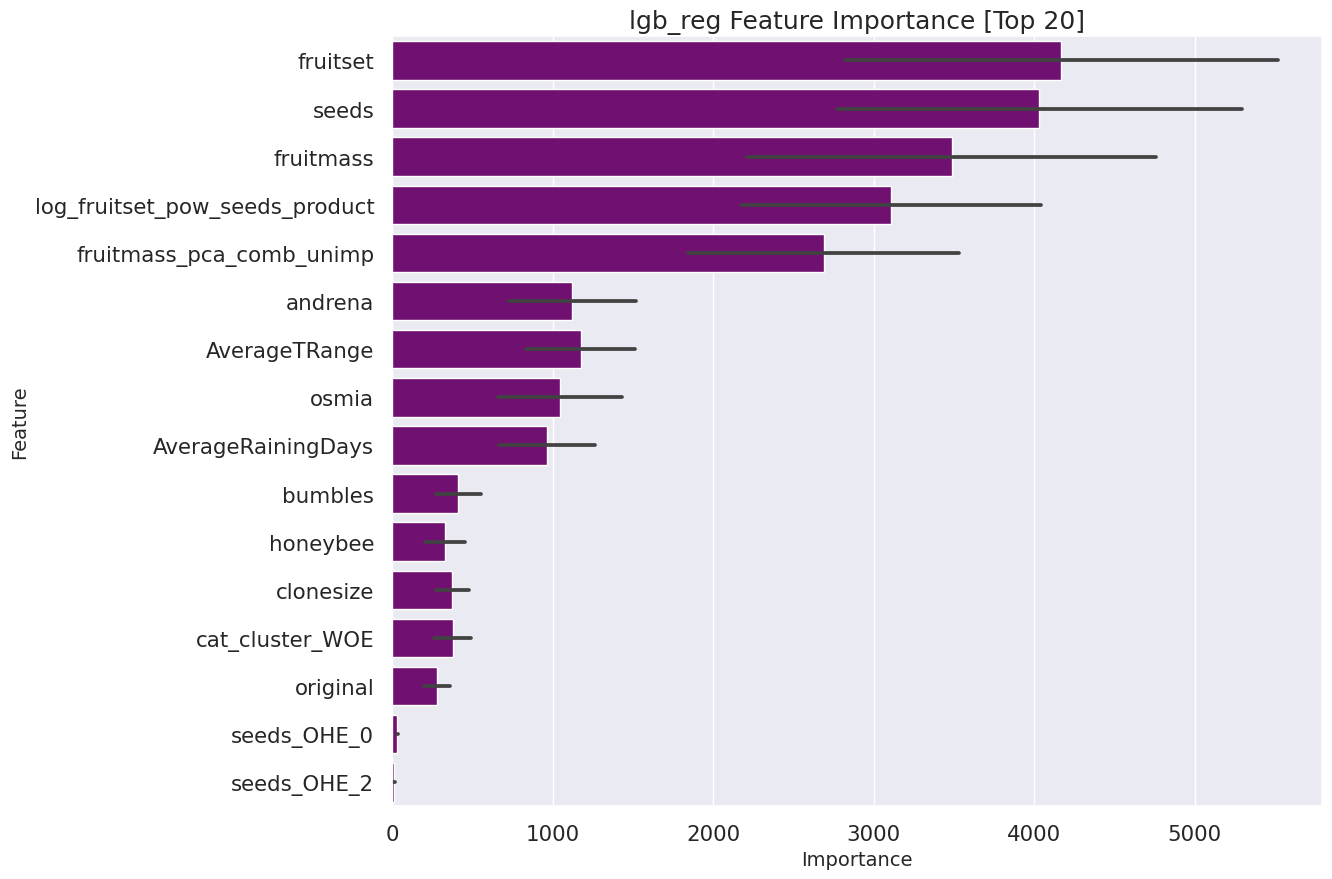

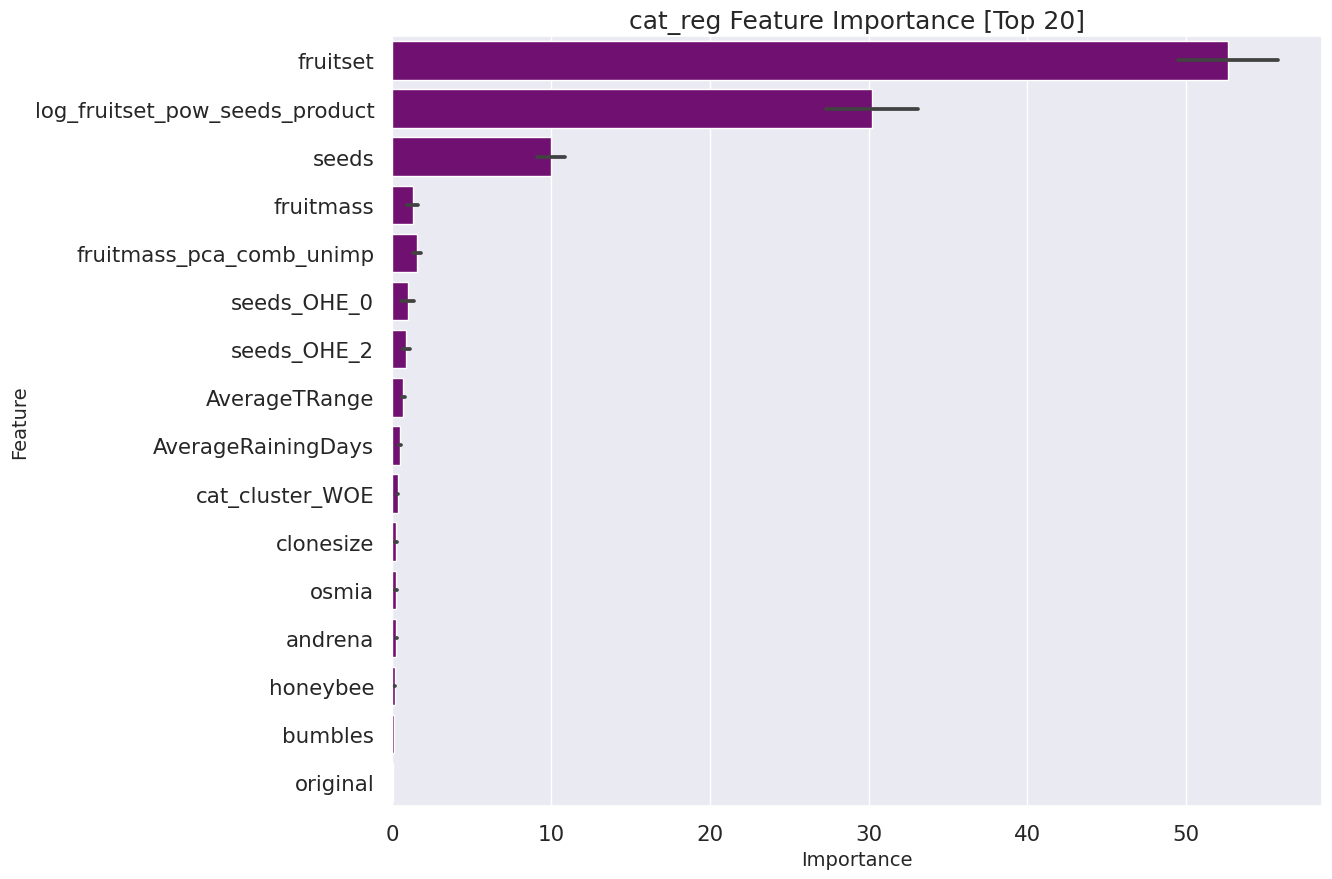

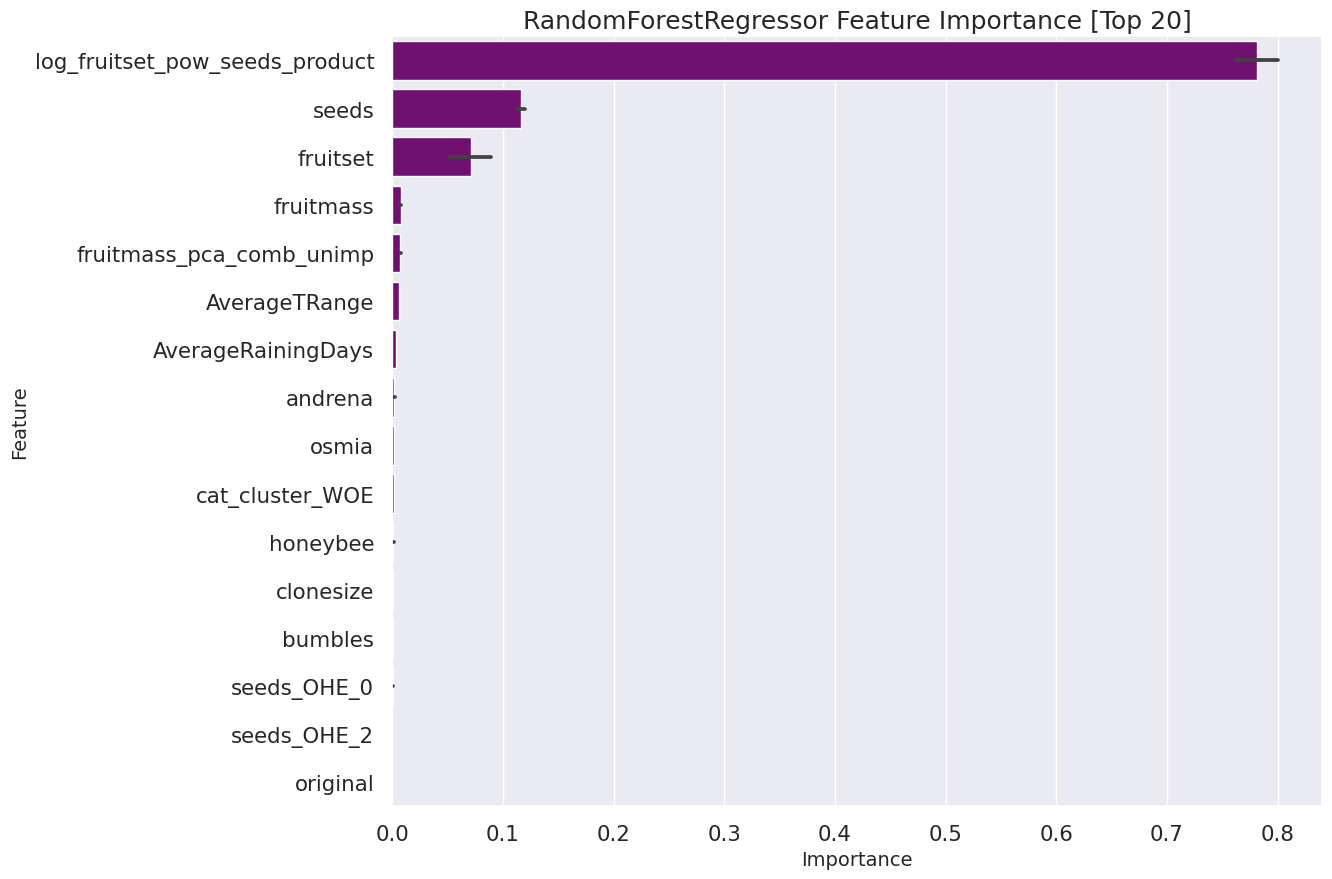

In [86]:
def visualize_importance(models, feature_cols, title, top=20):
    importances = []
    feature_importance = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df["importance"] = model.feature_importances_
        _df["feature"] = pd.Series(feature_cols)
        _df["fold"] = i
        _df = _df.sort_values('importance', ascending=False)
        _df = _df.head(top)
        feature_importance = pd.concat([feature_importance, _df], axis=0, ignore_index=True)
        
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    # display(feature_importance.groupby(["feature"]).mean().reset_index().drop('fold', axis=1))
    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=feature_importance, color='purple', errorbar='sd')
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.title(f'{title} Feature Importance [Top {top}]', fontsize=18)
    plt.grid(True, axis='x')
    plt.show()
    
for name, models in trained_models.items():
    visualize_importance(models, list(X_train.columns), name)

## 6.4 Results

please refer the discussion https://www.kaggle.com/competitions/playground-series-s3e14/discussion/407327 for postprocessing.

In [ ]:
sub = pd.read_csv('/kaggle/input/playground-series-s3e14/sample_submission.csv')
sub['yield'] = np.array([min(unique_targets, key = lambda x: abs(x - pred)) for pred in test_predss])
sub.to_csv('submission.csv',index=False)
sub